<a href="https://colab.research.google.com/github/danielchin-ck/ADALL_github/blob/main/project/6096089w_cda1c03_adall_project_2026_ver7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# No need to run
# Libraries used in this notebook
import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Modelling libraries
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Make wide tables easier to read in Colab
pd.set_option('display.max_columns', 100)

In [ ]:
# No need to run
import os
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
assert token, 'Missing Colab Secret: GITHUB_TOKEN'

os.environ['GITHUB_TOKEN'] = token
os.environ['GITHUB_USER'] = 'danielchin-ck'
os.environ['GITHUB_REPO'] = 'ADALL_github'
os.environ['GITHUB_EMAIL'] = 'danielchin.ck@gmail.com'

print('GitHub settings loaded. Token is not printed.')

In [ ]:
#No need to run
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')



OpenAI client is ready.


In [ ]:
#No need to run
#Version 1
bp_prompt = f"""
You are a Data Scientist of specialized experience in tree-based regression models (XGBoost, LightGBM, Random Forest) for actuarial and real-estate forecasting.
Your expertise is translating ambiguous socio-economic problems into rigorous ML objectives with clear business impact.

CONTEXT:
Mr. Chin faces a criticial retirement challenge: his Executive Apartment HDB flat is depreciating through lease decay, but a new MRT station near his flat will be completed after 2029,
potentially boosting its value. He needs to identify the optimal year within the next 5 to 10 years to downsize - balancing these opposite forces.

YOUR TASK:
Craft a complete ML modelling brief that addresses the following:

1. BUSINESS PROBLEM DEFINITION
   •	Describe the business problem you aim to address. Explain why it matters and who is affected.

2. PRIMARY BENEFICIARY PERSONA
   •	Identify the key beneficiary of the ML solution. Create a simple persona that captures details important for this project,
   such as the person’s goals, pain points, behaviours and how they would use the solution.

3. JTBD-FRAMED MODELLING OBJECTIVES
   •	Use the Job-To-Be-Done (JTBD) framework to shape your modelling objectives. State the job the user is trying to complete,
   and define your target variable and likely predictors based on this job.

FORMAT:
Respond in point forms

CONSTRAINTS:
Keep it concise and to the point.
Limit each section to maximum 200 characters per line.
"""

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=bp_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')



LLM response:
- **1) BUSINESS PROBLEM DEFINITION**
  - **Problem:** Forecast best downsizing year (next 5–10y) for HDB Exec apartment.
  - **Why it matters:** Flat value decays via lease term + may rise after new MRT completion.
  - **Impact:** Helps avoid overpaying on timing; reduces retirement risk for household cashflow.
  - **Affected:** Mr. Chin + co-owners; retirement planning; potential buyers/estate liquidity.

- **2) PRIMARY BENEFICIARY PERSONA**
  - **Persona:** “Kian Chin, 55–62, nearing retirement, owns Executive HDB.”
  - **Goal:** Choose downsizing year to maximize proceeds (or minimize loss) while maintaining housing stability.
  - **Pain points:** Unclear MRT price lift timing; uncertainty on lease decay vs transit premium.
  - **Behaviour:** Uses online price trends; waits for “right time”; needs a data-backed decision rule.
  - **Use:** Inputs address/lease/financial constraints → gets recommended year range + rationale.

- **3) JTBD-FRAMED MODELLING OBJECTIVES**
  

In [ ]:
#No need to run
#Version 2
bp_prompt = f"""
You are a Data Scientist of specialized experience in tree-based regression models (XGBoost, LightGBM, Random Forest) for actuarial and real-estate forecasting.
Your expertise is translating ambiguous socio-economic problems into rigorous ML objectives with clear business impact.

CONTEXT:
Mr. Chin faces a criticial retirement challenge: his 36 years old Executive Apartment HDB flat is depreciating through lease decay, but a new MRT station near his flat will be completed after 2029,
potentially boosting its value. He needs to identify the optimal year within the next 5 to 10 years to downsize - balancing these opposite forces.

YOUR TASK:
Craft a complete ML modelling brief that addresses the following:

1. BUSINESS PROBLEM DEFINITION
   •	Describe the business problem you aim to address. Explain why it matters and who is affected.

2. PRIMARY BENEFICIARY PERSONA
   •	Identify the key beneficiary of the ML solution. Create a simple persona that captures details important for this project,
   such as the person’s goals, pain points, behaviours and how they would use the solution.

3. JTBD-FRAMED MODELLING OBJECTIVES
   •	Use the Job-To-Be-Done (JTBD) framework to shape your modelling objectives. State the job the user is trying to complete,
   and define your target variable and likely predictors based on this job.

FORMAT:
Respond in point forms

CONSTRAINTS:
Keep it concise and to the point.
Limit each section to maximum 200 characters per line.
"""

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=bp_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')



LLM response:
- **1) Business Problem Definition**
  - Optimize best downsize timing (year) for an HDB Executive Apartment lease decay vs MRT value uplift.
  - Affects Mr. Chin’s retirement capital planning and housing affordability risk.
  - Deliver decision support: “Downsize year” choice within next 5–10 yrs.

- **2) Primary Beneficiary Persona**
  - **Persona:** 36yo owner-occupier of Exec Apartment HDB, planning retirement in 10–20 yrs.
  - **Goal:** Sell, downsize, and fund retirement while minimizing loss/overpay risk.
  - **Pain points:** Lease decay drag; uncertainty about MRT-driven uplift timing; limited time to analyze.
  - **Usage:** Inputs property + household + timeline; receives best year + expected value range.

- **3) JTBD-Framed Modelling Objectives**
  - **JTBD:** “Help me choose the year to sell/downsize so my net proceeds + affordability are maximized.”
  - **Target variable (regression):**
    - Predict **HDB resale price** (or **net proceeds**) by candidate yea

In [ ]:
#No need to run
prepare_prompt = f"""
You are a Data Scientist of specialized experience in tree-based regression models (XGBoost, LightGBM, Random Forest) for actuarial and real-estate forecasting.

CONTEXT:
When Mr. Chin’s HDB Executive Apartment in Pasir Ris approaches the post-MRT era (2030 onwards) and he need to fund his retirement, he want to identify the best year within 2030–2036 to downsize, so that he can maximize his net sale proceeds by capturing the Cross Island Line MRT premium before lease decay erodes his flat's value.“

Target Variable (Regression)
Primary Target:
Projected Net Sale Proceeds (selling price) for each candidate year t, where t ∈ [2030, 2031, ..., 2036].

Key Assumptions:
✅ Nominal proceeds only (no discounting)
✅ No P10/P50 guardrails or probabilistic optimization
✅ MRT operational by 2030 (no time covariates needed)
Per Straits Times (23 Mar 2026), MRT premium decay of $54,027 per 100m applies only beyond 400m. Since Mr. Chin's flat is at 200m, I have applied the full premium $54,027 with no decay.

Predictors (Feature Set):
Property Attributes: Remaining lease (months/years), flat age, floor level, unit size (m²), town (Pasir Ris), precinct proxies, flat type
Location/MRT: Distance to MRT (200m), baseline accessibility, MRT premium
Market Dynamics: Historical resale price index (town-level), recent transacted m² in Pasir Ris, resale supply trends

Excluded Predictors:
❌ Time covariates (year index t, event indicators for MRT phases) — MRT operational by 2030
❌ Macro variables (interest rates, wage growth, inflation) — outside scope

Dataset: 	https://raw.githubusercontent.com/danielchin-ck/ADALL_github/refs/heads/main/Project/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv

YOUR TASK:
Provide a clear a overview of how you prepared and modelled your data. You should describe the important choices you made, especially those that shape how the model behaves or how the results should be interpreted. You do not need to repeat every step of your code. Focus instead on what a decision maker needs to know when judging whether the solution is trustworthy and practical. You can consider covering the following with relevant screenshots of code and/or visualisation, including but not limited to:
•	Transforming predictors to uncover useful patterns
•	Balancing imbalance classes, if applicable
•	Modelling choices made

Use the Job-To-Be-Done (JTBD) framework to shape your modelling objectives. State the job the user is trying to complete,
and define your target variable and likely predictors based on this job.

Generate code using Python.

"""

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=prepare_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


LLM response:
Below is an overview you can use in a decision-maker–friendly “model preparation & modelling” section. I’ll frame it with the JTBD job, explain the modelling choices that materially affect behaviour, and include Python code snippets showing key transformations and how the model is trained for each candidate year 2030–2036.

---

## 1) JTBD framing (what Mr. Chin is trying to do)

**Job-to-be-Done:**  
Mr. Chin wants to choose the *best year between 2030 and 2036* to downsize so that he **maximizes his expected net sale proceeds**, by capturing the **Cross Island Line MRT premium** while not suffering (lease-decay–driven) erosion of his flat’s value.

**Decision output needed:**  
For each candidate year \(t \in \{2030, 2031, \dots, 2036\}\), estimate **Projected Net Sale Proceeds**. Then select the maximizing year.

---

## 2) Target variable and how it maps to ML

### Primary target (regression)
For each record in the training data (historical resale transactions), the 

In [1]:
# Libraries used in this notebook
import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Modelling libraries used later in Session 2
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Make wide tables easier to read in Colab
pd.set_option('display.max_columns', 100)

In [2]:
RUN_API_CELLS = True
OPENAI_MODEL = 'gpt-5.4-nano'
client = None

if RUN_API_CELLS == True:
    from google.colab import userdata
    from openai import OpenAI

    api_key = userdata.get('OPENAI_API_KEY')
    client = OpenAI(api_key=api_key)
    print('OpenAI client is ready.')
else:
    print('Manual chatbot mode. Copy the prompts when they appear.')

OpenAI client is ready.


In [3]:
github_raw_url = "https://raw.githubusercontent.com/danielchin-ck/ADALL_github/refs/heads/main/Project/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"

df = pd.read_csv(github_raw_url)

print('Dataset loaded successfully.')
print('Shape:', df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (237194, 11)


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [ ]:
#No need to run
buss_prompt = f"""

You are an expert data scientist with experience in tree-based regression models.
Help me translate this business problem into a modelling objective.

Business problem: Mr. Chin faces a criticial retirement challenge: his 36 years old Executive Apartment HDB flat is depreciating through lease decay,
but a new MRT station near his flat will be completed after 2029,potentially boosting its value. He needs to identify the optimal year within the next 5 to 10 years to downsize - balancing these opposite forces.

Dataset context: {df}

Please answer:

1. What should the modelling objective be?
2. What is the most meaningful target column?
3. Which metric would be easiest to explain to business users?
4. Who are the main stakeholders?
5. What are three risks or pitfalls?

Respond in point forms

CONSTRAINTS:
Keep it concise and to the point.
Limit each section to maximum 200 characters per line.
"""

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=buss_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


LLM response:
1) **Modelling objective**
- Predict future resale price for each flat at candidate years (next 5–10 yrs).
- Choose **optimal downsizing year** that maximizes expected sale proceeds (or net gain vs holding).

2) **Most meaningful target column**
- **resale_price** (price at observation month).
- For year-choice: model **resale_price at future year** using remaining_lease, macro time, and station-boost features.

3) **Easiest metric to explain to business users**
- **MAPE of resale_price** (% error).
- Alternative: **RMSE** (dollar error) if users prefer $ impact.

4) **Main stakeholders**
- Mr. Chin (personal decision-maker).
- HDB/real-estate advisors & mortgage/financial planners.
- Data/analytics team building the model.
- Policy/urban planners indirectly (MRT impact assumptions).

5) **Three risks / pitfalls**
- **Data leakage**: using post-event price info when predicting pre-event.
- **Non-causality**: MRT proximity correlations ≠ true station effect.
- **Time shif

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237194 entries, 0 to 237193
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                237194 non-null  object 
 1   town                 237194 non-null  object 
 2   flat_type            237194 non-null  object 
 3   block                237194 non-null  object 
 4   street_name          237194 non-null  object 
 5   storey_range         237194 non-null  object 
 6   floor_area_sqm       237194 non-null  float64
 7   flat_model           237194 non-null  object 
 8   lease_commence_date  237194 non-null  int64  
 9   remaining_lease      237194 non-null  object 
 10  resale_price         237194 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.9+ MB


In [5]:
df.columns.tolist()

['month',
 'town',
 'flat_type',
 'block',
 'street_name',
 'storey_range',
 'floor_area_sqm',
 'flat_model',
 'lease_commence_date',
 'remaining_lease',
 'resale_price']

In [6]:
print('\nColumns before cleaning:')
print(df.columns.tolist())


Columns before cleaning:
['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price']


In [ ]:
data_preview = df.head(10).to_string()
print(data_preview[:1500])

     month        town flat_type block        street_name storey_range  floor_area_sqm      flat_model  lease_commence_date     remaining_lease  resale_price
0  2017-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12            44.0        Improved                 1979  61 years 04 months      232000.0
1  2017-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03            67.0  New Generation                 1978  60 years 07 months      250000.0
2  2017-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03            67.0  New Generation                 1980  62 years 05 months      262000.0
3  2017-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06            68.0  New Generation                 1980   62 years 01 month      265000.0
4  2017-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03            67.0  New Generation                 1980  62 years 05 months      265000.0
5  2017-01  ANG MO KIO    3 ROOM   150   ANG MO KIO 

In [ ]:
preview_prompt = f"""

Here are the first 10 rows of HDB resale pricing dataset:

{data_preview}

Questions:
1. What does each row appear to represent?
2. Which column is likely the target for a price prediction model?
3. What are 3 possible data quality checks we should perform before modelling?

Keep the answer short and practical.
"""

print('Prompt to send:')
print(preview_prompt[:2000])

if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=preview_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

Prompt to send:


Here are the first 10 rows of HDB resale pricing dataset:

     month        town flat_type block        street_name storey_range  floor_area_sqm      flat_model  lease_commence_date     remaining_lease  resale_price
0  2017-01  ANG MO KIO    2 ROOM   406  ANG MO KIO AVE 10     10 TO 12            44.0        Improved                 1979  61 years 04 months      232000.0
1  2017-01  ANG MO KIO    3 ROOM   108   ANG MO KIO AVE 4     01 TO 03            67.0  New Generation                 1978  60 years 07 months      250000.0
2  2017-01  ANG MO KIO    3 ROOM   602   ANG MO KIO AVE 5     01 TO 03            67.0  New Generation                 1980  62 years 05 months      262000.0
3  2017-01  ANG MO KIO    3 ROOM   465  ANG MO KIO AVE 10     04 TO 06            68.0  New Generation                 1980   62 years 01 month      265000.0
4  2017-01  ANG MO KIO    3 ROOM   601   ANG MO KIO AVE 5     01 TO 03            67.0  New Generation                 1980  62 years

In [7]:
# Build payload text step by step.
# Payload text is a short profile of the dataset.
# It is safer and smaller than sending the full dataset to the LLM.

payload_text = ''

# 1. Shape
payload_text += '=== SHAPE ===\n'
payload_text += 'Rows: ' + str(df.shape[0]) + '\n'
payload_text += 'Columns: ' + str(df.shape[1]) + '\n\n'

# 2. Column names and data types
payload_text += '=== COLUMNS AND DATA TYPES ===\n'
payload_text += df.dtypes.to_string()
payload_text += '\n\n'

# 3. Numeric summary
payload_text += '=== NUMERIC SUMMARY ===\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()
payload_text += '\n\n'

# 4. Missing values
payload_text += '=== MISSING VALUES ===\n'
missing_table = pd.DataFrame()
missing_table['missing_count'] = df.isna().sum()
missing_table['missing_pct'] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += missing_table.to_string()
payload_text += '\n\n'

# 5. Unique values per column
payload_text += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
payload_text += unique_table.to_string()
payload_text += '\n\n'

# 6. Correlation between numeric columns
payload_text += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table = df.corr(numeric_only=True).round(2)
payload_text += correlation_table.to_string()
payload_text += '\n\n'

# 7. Top 10 values for categorical columns
payload_text += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    payload_text += 'No categorical columns found.\n'
else:
    for col in categorical_columns:
        payload_text += '\nColumn: ' + col + '\n'
        payload_text += df[col].value_counts(dropna=False).head(10).to_string()
        payload_text += '\n'

payload_text += '\n'

# 8. Simple warning checks
payload_text += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)

payload_text += 'Possible ID-like columns: ' + str(id_like_columns) + '\n'
payload_text += 'Constant columns: ' + str(constant_columns) + '\n'
payload_text += 'Duplicate rows: ' + str(df.duplicated().sum()) + '\n'

print(payload_text)

# This cell builds a short dataset profile called payload_text.
# Instead of sending the full dataset to the LLM, we send summary information only.
# The payload includes shape, column types, numeric summary, missing values, unique counts, correlations, and common category values.
# It also adds simple warning checks for possible ID-like columns, constant columns, and duplicate rows.
# This helps the LLM comment on data readiness without needing every row of the dataset.

=== SHAPE ===
Rows: 237194
Columns: 11

=== COLUMNS AND DATA TYPES ===
month                   object
town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64

=== NUMERIC SUMMARY ===
       floor_area_sqm  lease_commence_date  resale_price
count       237194.00            237194.00     237194.00
mean            96.69              1996.59     533134.98
std             24.02                14.38     191348.81
min             31.00              1966.00     140000.00
25%             81.00              1985.00     390000.00
50%             93.00              1997.00     500000.00
75%            112.00              2012.00     640000.00
max            366.70              2022.00    1728000.00

=== MISSING VALUES ===
                     missi

In [ ]:
quality_prompt = f"""
You are helping a data analytics student prepare a HDB resale pricing dataset for modelling.

Dataset profile:
{payload_text}

Task:
1. List all data quality or modelling-readiness issues.
2. Suggest action to remedy the issues.

Important:
- Do not assume external knowledge.
- Do not say to drop a column just because it is listed as a warning.
- Keep the answer concise.
"""


if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=quality_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')

# This cell asks the LLM to review the dataset profile for modelling-readiness issues.
# The LLM does not receive the full dataset, only the summary stored in payload_text.
# The prompt asks for possible issues and practical remedies.
# The instructions help prevent the LLM from making unsupported assumptions or dropping columns too quickly.
# If the API client is connected, the prompt is sent automatically.
# Otherwise, students can copy the prompt and use the chatbot manually.


LLM response:
## 1) Data quality / modelling-readiness issues

1. **Duplicate rows present**
   - `Duplicate rows: 316` (no further detail given)
   - Risk: inflates sample size and can bias model training/evaluation.

2. **High-cardinality categorical features**
   - `block` (2775 unique), `street_name` (578), `month` (116), `remaining_lease` (702)
   - Risk: severe dimensionality increase (especially with one-hot encoding), sparsity, overfitting.

3. **Potentially non-numeric “lease” representation**
   - `remaining_lease` is **object** with values like `"94 years 10 months"`
   - Risk: not directly usable for numeric modelling; ordering/interval relationships may be unclear.

4. **Imperfect / ambiguous temporal fields**
   - `month` is **object** (116 unique) and there is also `lease_commence_date` (int)
   - Risk: if `month` ordering is not parsed correctly as a date/time index, time-based validation and trend features may be wrong.

5. **“Lease commence date” granularity may be c

In [ ]:
quality_prompt = f"""
You are helping a data analytics student prepare a HDB resale pricing dataset for modelling.

Dataset profile:
{payload_text}

Task:
1. Provide Python code to list all duplicate rows for observation.

Important:
- Do not assume external knowledge.
- Do not say to drop a column just because it is listed as a warning.
- Keep the answer concise.
"""


if client is not None:
    response = client.responses.create(
        model=OPENAI_MODEL,
        input=quality_prompt
    )
    print('\nLLM response:')
    print(response.output_text)
else:
    print('\nNo API response because client is not connected. Copy the prompt above into your chatbot.')


LLM response:
```python
import pandas as pd

# df = your DataFrame

# 1) Find duplicate rows (exact duplicates across all columns)
dup_mask = df.duplicated(keep=False)
dup_rows = df.loc[dup_mask].sort_values(list(df.columns))  # optional sort for readability

# 2) List them
print(f"Number of rows that are part of duplicate sets: {dup_rows.shape[0]}")
print(dup_rows)

# (Optional) If you want each duplicate set grouped and printed with counts:
# print(df[dup_mask].groupby(list(df.columns)).size().reset_index(name="count"))
```


In [ ]:
import pandas as pd

# df = your dataframe (must contain the 11 columns shown)

# Find duplicate rows (entire-row duplicates)
dup_mask = df.duplicated(keep=False)  # marks all occurrences of duplicates

dup_rows = df.loc[dup_mask].copy()

print(f"Number of duplicate-row records (including all copies): {len(dup_rows)}")
print("Duplicate rows (all columns):")
print(dup_rows)

Number of duplicate-row records (including all copies): 631
Duplicate rows (all columns):
          month          town flat_type block       street_name storey_range  \
224     2017-01   BUKIT MERAH    4 ROOM   106    HENDERSON CRES     07 TO 09   
243     2017-01   BUKIT MERAH    4 ROOM   106    HENDERSON CRES     07 TO 09   
304     2017-01  CENTRAL AREA    3 ROOM   271          QUEEN ST     16 TO 18   
305     2017-01  CENTRAL AREA    3 ROOM   271          QUEEN ST     16 TO 18   
505     2017-01   JURONG EAST    4 ROOM   265       TOH GUAN RD     04 TO 06   
...         ...           ...       ...   ...               ...          ...   
232828  2026-03      SENGKANG    5 ROOM  224C  COMPASSVALE WALK     07 TO 09   
234808  2026-03     TOA PAYOH    4 ROOM  103B    BIDADARI PK DR     07 TO 09   
234811  2026-03     TOA PAYOH    4 ROOM  103B    BIDADARI PK DR     07 TO 09   
235207  2026-04     WOODLANDS    3 ROOM   148   WOODLANDS ST 13     01 TO 03   
235208  2026-04     WOODLANDS 

In [8]:
import pandas as pd
import numpy as np

# Make a copy to preserve the original df
cleaned_df = df.copy()

# 1. Handle duplicate rows
# Remove exact duplicate rows
initial_rows = len(cleaned_df)
cleaned_df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows - len(cleaned_df)} duplicate rows.")

# 2. Reduce/encode high-cardinality categoricals appropriately
# Filter the town to 'Pasir Ris' and flat_type to 'Executive'
cleaned_df = cleaned_df[cleaned_df['town'].str.upper() == 'PASIR RIS']
cleaned_df = cleaned_df[cleaned_df['flat_type'].str.upper() == 'EXECUTIVE']
#cleaned_df = cleaned_df[cleaned_df['flat_model'].str.upper() == 'APARTMENT']
print(f"Filtered to 'Pasir Ris' town,'Executive' flat_type. Remaining rows: {len(cleaned_df)}")

# 4. Ensure time parsing for 'month' and create 'transacted-year'
cleaned_df['month'] = pd.to_datetime(cleaned_df['month'])
cleaned_df['transaction_year'] = cleaned_df['month'].dt.year
cleaned_df['transaction_month_num'] = cleaned_df['month'].dt.month # Keep month number for potential seasonality
# As per instruction 'consider to drop [month]' and 'replace the month' with 'transacted-year'
cleaned_df.drop('month', axis=1, inplace=True)

# 3. Convert `remaining_lease` to numeric (whole years only, ignoring months)
def parse_remaining_lease_years(lease_str):
    if pd.isna(lease_str):
        return np.nan
    lease_str = str(lease_str).lower()
    years = 0
    if 'year' in lease_str:
        year_part = lease_str.split('year')[0].strip()
        try:
            years = int(year_part)
        except ValueError:
            pass # Handle cases where year_part might not be an integer
    return years

cleaned_df['remaining_lease_years'] = cleaned_df['remaining_lease'].apply(parse_remaining_lease_years)

# 5. Create “lease age (yrs)” features: years_since_commence (as whole number)
# Calculate current age of the flat at the time of transaction
# 'lease_commence_date' is int representing year, 'transaction_year' is also int
cleaned_df['age_of_flat_at_transaction'] = cleaned_df['transaction_year'] - cleaned_df['lease_commence_date']

# 8. Sanity checks for categorical consistency (trim whitespace, standardize casing)
categorical_cols_to_clean = ['town', 'flat_type', 'block', 'street_name', 'storey_range', 'flat_model']
for col in categorical_cols_to_clean:
    if col in cleaned_df.columns and cleaned_df[col].dtype == 'object':
        cleaned_df[col] = cleaned_df[col].astype(str).str.strip().str.lower()

# 7. Feature engineering for price modelling: price_per_sqm
# Check for zero floor_area_sqm to avoid division by zero
#if (cleaned_df['floor_area_sqm'] == 0).any():
#    print("Warning: 'floor_area_sqm' contains zero values. Handling for 'price_per_sqm' calculation.")
#    cleaned_df['price_per_sqm'] = cleaned_df.apply(lambda row: row['resale_price'] / row['floor_area_sqm'] if row['floor_area_sqm'] != 0 else np.nan, axis=1)
#else:
#    cleaned_df['price_per_sqm'] = cleaned_df['resale_price'] / cleaned_df['floor_area_sqm']

# Function to parse storey_range and group it numerically
def get_storey_group(storey_range_str):
    if pd.isna(storey_range_str):
        return np.nan

    # The format is 'XX TO YY', convert to lower case first due to previous cleaning step
    try:
        # Extract the lower bound of the storey range
        lower_bound = int(storey_range_str.split(' to ')[0])
        # Grouping: 01-03 is group 1, 04-06 is group 2, etc.
        # (lower_bound - 1) // 3 + 1 will correctly map these
        return (lower_bound - 1) // 3 + 1
    except (ValueError, IndexError):
        return np.nan # Handle cases where parsing might fail

# Apply the function to create the new column
cleaned_df['storey_range_group'] = cleaned_df['storey_range'].apply(get_storey_group)

print("Added 'storey_range_group' column.")


# 6. Outlier treatment (quantify and document, but do not modify at this stage as per instruction)
print("\n--- Outlier Detection Report (No modification performed) ---")
# Only consider columns that are expected to be numeric and relevant for outlier analysis
#numeric_cols_for_outliers = ['floor_area_sqm', 'resale_price', 'remaining_lease_years', 'age_of_flat_at_transaction', 'price_per_sqm']
numeric_cols_for_outliers = ['floor_area_sqm', 'resale_price', 'remaining_lease_years', 'age_of_flat_at_transaction', 'storey_range_group']

for col in numeric_cols_for_outliers:
    if col in cleaned_df.columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Count values outside the IQR bounds, ignoring NaNs
        outliers_count = cleaned_df[(cleaned_df[col] < lower_bound) | (cleaned_df[col] > upper_bound)][col].count()
        print(f"Column '{col}': {outliers_count} outliers detected (outside 1.5*IQR). Min: {cleaned_df[col].min():.2f}, Max: {cleaned_df[col].max():.2f}")
        if outliers_count > 0:
            # Print a few examples of outliers, handle potential empty slices
            example_outliers = cleaned_df[(cleaned_df[col] < lower_bound) | (cleaned_df[col] > upper_bound)][[col]].head()
            if not example_outliers.empty:
                print(f"  Example outliers for '{col}':\n{example_outliers.to_string()}")


#print("\n--- Updated Cleaned DataFrame Info ---")
#cleaned_df.info()
#print("\nUpdated Cleaned DataFrame head (with 'storey_range_group'):")
#print(cleaned_df[['storey_range', 'storey_range_group']].head().to_string())



print("\n--- Cleaned DataFrame Info ---")
cleaned_df.info()
print("\nCleaned DataFrame head:")
print(cleaned_df.head().to_string())

Removed 316 duplicate rows.
Filtered to 'Pasir Ris' town,'Executive' flat_type. Remaining rows: 1748
Added 'storey_range_group' column.

--- Outlier Detection Report (No modification performed) ---
Column 'floor_area_sqm': 35 outliers detected (outside 1.5*IQR). Min: 141.00, Max: 190.00
  Example outliers for 'floor_area_sqm':
       floor_area_sqm
705             161.0
707             165.0
7093            158.0
8947            158.0
12584           156.0
Column 'resale_price': 3 outliers detected (outside 1.5*IQR). Min: 470500.00, Max: 1260000.00
  Example outliers for 'resale_price':
        resale_price
130520     1238000.0
209856     1250000.0
229886     1260000.0
Column 'remaining_lease_years': 0 outliers detected (outside 1.5*IQR). Min: 61.00, Max: 78.00
Column 'age_of_flat_at_transaction': 0 outliers detected (outside 1.5*IQR). Min: 21.00, Max: 38.00
Column 'storey_range_group': 0 outliers detected (outside 1.5*IQR). Min: 1.00, Max: 6.00

--- Cleaned DataFrame Info ---
<class '

In [9]:
cleaned_df['flat_model_group'] = pd.factorize(cleaned_df['flat_model'])[0]

print("Converted 'flat_model' to numeric 'flat_model_group'.")
print(cleaned_df[['flat_model', 'flat_model_group']].head())

Converted 'flat_model' to numeric 'flat_model_group'.
     flat_model  flat_model_group
703   apartment                 0
704  maisonette                 1
705   apartment                 0
706  maisonette                 1
707  maisonette                 1


In [10]:
cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1748 entries, 703 to 229984
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   town                        1748 non-null   object 
 1   flat_type                   1748 non-null   object 
 2   block                       1748 non-null   object 
 3   street_name                 1748 non-null   object 
 4   storey_range                1748 non-null   object 
 5   floor_area_sqm              1748 non-null   float64
 6   flat_model                  1748 non-null   object 
 7   lease_commence_date         1748 non-null   int64  
 8   remaining_lease             1748 non-null   object 
 9   resale_price                1748 non-null   float64
 10  transaction_year            1748 non-null   int32  
 11  transaction_month_num       1748 non-null   int32  
 12  remaining_lease_years       1748 non-null   int64  
 13  age_of_flat_at_transaction  1748 n

In [11]:
categorical_columns = cleaned_df.select_dtypes(include=['object', 'category']).columns.tolist()
print(categorical_columns)
categorical_columns

['town', 'flat_type', 'block', 'street_name', 'storey_range', 'flat_model', 'remaining_lease']


['town',
 'flat_type',
 'block',
 'street_name',
 'storey_range',
 'flat_model',
 'remaining_lease']

In [12]:
cleaned_df.select_dtypes(include=['object', 'category']).info()

<class 'pandas.core.frame.DataFrame'>
Index: 1748 entries, 703 to 229984
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   town             1748 non-null   object
 1   flat_type        1748 non-null   object
 2   block            1748 non-null   object
 3   street_name      1748 non-null   object
 4   storey_range     1748 non-null   object
 5   flat_model       1748 non-null   object
 6   remaining_lease  1748 non-null   object
dtypes: object(7)
memory usage: 109.2+ KB


In [13]:
price_index_url = "https://raw.githubusercontent.com/danielchin-ck/ADALL_github/refs/heads/main/Project/Executive_Resale_Price_Index%20%E2%80%93%202007%20Q1%20to%202026%20Q2.csv"
resale_price_index_df = pd.read_csv(price_index_url)

print("Resale price index loaded successfully.")
print(resale_price_index_df.head())

Resale price index loaded successfully.
  Quarter  Year Quarter_Label  Average_Price_SGD  Index_Base_2007Q2
0      Q1  2007       2007 Q1             410625               98.8
1      Q2  2007       2007 Q2             415417              100.0
2      Q3  2007       2007 Q3             432375              104.1
3      Q4  2007       2007 Q4             429800              103.5
4      Q1  2008       2008 Q1             475971              114.6


In [14]:
print("Preparing `cleaned_df` for merge by creating 'Quarter' column...")

# Create a 'Quarter' column in cleaned_df based on 'transaction_month_num'
cleaned_df['Quarter'] = cleaned_df['transaction_month_num'].apply(
    lambda x: 'Q1' if x in [1, 2, 3] else
              'Q2' if x in [4, 5, 6] else
              'Q3' if x in [7, 8, 9] else
              'Q4'
)

print("Joining `resale_price_index_df` with `cleaned_df` on 'Year' and 'Quarter'...")

# Perform a left merge using 'transaction_year' from cleaned_df and 'Year' from historical_price_index_df
# and the newly created 'Quarter' column from both dataframes.
merged_df = pd.merge(cleaned_df,
                     resale_price_index_df[['Year', 'Quarter', 'Index_Base_2007Q2']],
                     left_on=['transaction_year', 'Quarter'],
                     right_on=['Year', 'Quarter'],
                     how='left')

# Drop the redundant 'Year' column from the merge (from resale_price_index_df)
# and the temporary 'Quarter' column from cleaned_df if it's no longer needed.
merged_df.drop(columns=['Year', 'Quarter'], inplace=True)

# Update cleaned_df to be the merged dataframe
cleaned_df = merged_df

print("Merge complete. Displaying head and info of the updated `cleaned_df`.")
cleaned_df.info()
print("\nUpdated Cleaned DataFrame head (with 'Index_Base_2007Q2' column):")
print(cleaned_df.head().to_string())

Preparing `cleaned_df` for merge by creating 'Quarter' column...
Joining `resale_price_index_df` with `cleaned_df` on 'Year' and 'Quarter'...
Merge complete. Displaying head and info of the updated `cleaned_df`.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   town                        1748 non-null   object 
 1   flat_type                   1748 non-null   object 
 2   block                       1748 non-null   object 
 3   street_name                 1748 non-null   object 
 4   storey_range                1748 non-null   object 
 5   floor_area_sqm              1748 non-null   float64
 6   flat_model                  1748 non-null   object 
 7   lease_commence_date         1748 non-null   int64  
 8   remaining_lease             1748 non-null   object 
 9   resale_price                1748 non-null   float

### Imputing Remaining Missing `Index_Base_2007Q2` Values

It seems there are still some missing values in the `Index_Base_2007Q2` column. To ensure data completeness and consistency for downstream calculations, I will explicitly fill these missing values using `ffill()` (forward fill), which propagates the last valid observation forward.

After imputation, `deflated_resale_price` and `block_encoded` will be re-calculated, as they are dependent on the `Index_Base_2007Q2` column.

In [15]:
print("--- Imputing missing Index_Base_2007Q2 values and regenerating dependent columns ---")

# 1. Sort by time to ensure correct forward filling
# 'transaction_year' and 'transaction_month_num' define the time order
cleaned_df = cleaned_df.sort_values(by=['transaction_year', 'transaction_month_num']).reset_index(drop=True)

# 2. Impute missing Index_Base_2007Q2 with the previous valid quarter's index
# Using ffill (forward fill) to carry forward the last valid observation
initial_missing_count = cleaned_df['Index_Base_2007Q2'].isna().sum()
cleaned_df['Index_Base_2007Q2'] = cleaned_df['Index_Base_2007Q2'].ffill()

# After ffill, there might still be NaNs at the beginning if the first values were missing.
# For robustness, we can backfill any remaining NaNs (e.g., if the very first entries were missing).
cleaned_df['Index_Base_2007Q2'] = cleaned_df['Index_Base_2007Q2'].bfill()

# Report on imputation
filled_count = initial_missing_count - cleaned_df['Index_Base_2007Q2'].isna().sum()
print(f"Imputed {filled_count} missing values in 'Index_Base_2007Q2' using previous/next quarter's index.")

# 3. Regenerate 'deflated_resale_price' with the imputed Index_Base_2007Q2
cleaned_df['deflated_resale_price'] = cleaned_df['resale_price'] * 100 / cleaned_df['Index_Base_2007Q2']
print("'deflated_resale_price' column regenerated.")

# 4. Regenerate 'block_encoded' using the new 'deflated_resale_price'
# (Re-using the smoothing parameter 'm' from previous steps, assuming it's still 30)
m = 30 # From previous context (cell aaaxuwL4ZvSh)

# Calculate global mean of deflated_resale_price across all blocks in Pasir Ris
# Ensure to skipna=True in case any deflated_resale_price remained NaN
global_mean_deflated_price = cleaned_df['deflated_resale_price'].mean(skipna=True)

# Calculate block_mean and count for each block using the regenerated deflated_resale_price
block_stats = cleaned_df.groupby('block')['deflated_resale_price'].agg(
    block_mean='mean',
    count='count'
).reset_index()

# Merge block statistics back to cleaned_df
# Drop existing block_mean and count columns if they exist from a prior run
if 'block_mean' in cleaned_df.columns: cleaned_df.drop(columns=['block_mean'], inplace=True)
if 'count' in cleaned_df.columns: cleaned_df.drop(columns=['count'], inplace=True)

cleaned_df = cleaned_df.merge(block_stats, on='block', how='left')

# Calculate block_encoded using the formula:
# block_encoded = (count / (count + m)) * block_mean + (m / (count + m)) * global_mean
cleaned_df['block_encoded'] = (
    (cleaned_df['count'] * cleaned_df['block_mean']) +
    (m * global_mean_deflated_price)
) / (cleaned_df['count'] + m)

print("'block_encoded' column regenerated.")

# Drop the temporary columns 'block_mean' and 'count' as they are no longer needed
cleaned_df.drop(columns=['block_mean', 'count'], inplace=True)

print("--- Regeneration complete ---")

# Display info and head to confirm changes
print("\nCleaned DataFrame info after imputation and regeneration:")
cleaned_df.info()
print("\nCleaned DataFrame head after imputation and regeneration:")
print(cleaned_df[['Index_Base_2007Q2', 'deflated_resale_price', 'block_encoded']].head().to_string())


--- Imputing missing Index_Base_2007Q2 values and regenerating dependent columns ---
Imputed 25 missing values in 'Index_Base_2007Q2' using previous/next quarter's index.
'deflated_resale_price' column regenerated.
'block_encoded' column regenerated.
--- Regeneration complete ---

Cleaned DataFrame info after imputation and regeneration:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   town                        1748 non-null   object 
 1   flat_type                   1748 non-null   object 
 2   block                       1748 non-null   object 
 3   street_name                 1748 non-null   object 
 4   storey_range                1748 non-null   object 
 5   floor_area_sqm              1748 non-null   float64
 6   flat_model                  1748 non-null   object 
 7   lease_commence_date         1748 no

### Investigating Missing Values in `Index_Base_2007Q2`

Let's first identify the rows in `cleaned_df` that have missing `Index_Base_2007Q2` values.

In [ ]:
#No need to run
missing_index_rows = cleaned_df[cleaned_df['Index_Base_2007Q2'].isna()]

print(f"Number of rows with missing 'Index_Base_2007Q2': {len(missing_index_rows)}")
print("Transaction years and months for rows with missing 'Index_Base_2007Q2':")
display(missing_index_rows[['transaction_year', 'transaction_month_num']].drop_duplicates().sort_values(by=['transaction_year', 'transaction_month_num']))

print("\nNow, let's look at the available years and quarters in the `resale_price_index_df`:")
display(resale_price_index_df[['Year', 'Quarter']].drop_duplicates().sort_values(by=['Year', 'Quarter']).to_string())

Number of rows with missing 'Index_Base_2007Q2': 25
Transaction years and months for rows with missing 'Index_Base_2007Q2':


,transaction_year,transaction_month_num
1643,2026,7
1715,2026,8



Now, let's look at the available years and quarters in the `resale_price_index_df`:


'    Year Quarter\n0   2007      Q1\n1   2007      Q2\n2   2007      Q3\n3   2007      Q4\n4   2008      Q1\n5   2008      Q2\n6   2008      Q3\n7   2008      Q4\n8   2009      Q1\n9   2009      Q2\n10  2009      Q3\n11  2009      Q4\n12  2010      Q1\n13  2010      Q2\n14  2010      Q3\n15  2010      Q4\n16  2011      Q1\n17  2011      Q2\n18  2011      Q3\n19  2011      Q4\n20  2012      Q1\n21  2012      Q2\n22  2012      Q3\n23  2012      Q4\n24  2013      Q1\n25  2013      Q2\n26  2013      Q3\n27  2013      Q4\n28  2014      Q1\n29  2014      Q2\n30  2014      Q3\n31  2014      Q4\n32  2015      Q1\n33  2015      Q2\n34  2015      Q3\n35  2015      Q4\n36  2016      Q1\n37  2016      Q2\n38  2016      Q3\n39  2016      Q4\n40  2017      Q1\n41  2017      Q2\n42  2017      Q3\n43  2017      Q4\n44  2018      Q1\n45  2018      Q2\n46  2018      Q3\n47  2018      Q4\n48  2019      Q1\n49  2019      Q2\n50  2019      Q3\n51  2019      Q4\n52  2020      Q1\n53  2020      Q2\n54  2020 

In [ ]:
#No need to run
print("Creating 'deflated_resale_price' column...")

# Calculate deflated_resale_price
# Handle potential division by zero or NaN in Index_Base_2007Q2 by letting pandas propagate NaN if denominator is NaN.
cleaned_df['deflated_resale_price'] = cleaned_df['resale_price'] * 100 / cleaned_df['Index_Base_2007Q2']

print("Deflated resale price column created successfully.")

print("\nUpdated Cleaned DataFrame head (with 'deflated_resale_price' column):")
print(cleaned_df[['resale_price', 'Index_Base_2007Q2', 'deflated_resale_price']].head().to_string())

print("\nCleaned DataFrame info:")
cleaned_df.info()

Creating 'deflated_resale_price' column...
Deflated resale price column created successfully.

Updated Cleaned DataFrame head (with 'deflated_resale_price' column):
   resale_price  Index_Base_2007Q2  deflated_resale_price
0      552888.0              164.2          336716.199756
1      598000.0              164.2          364190.012180
2      600000.0              164.2          365408.038977
3      638000.0              164.2          388550.548112
4      728000.0              164.2          443361.753959

Cleaned DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   town                        1748 non-null   object 
 1   flat_type                   1748 non-null   object 
 2   block                       1748 non-null   object 
 3   street_name                 1748 non-null   object 
 4   storey_r

In [ ]:
# No need to run
# Define smoothing parameter
m = 30

# Calculate global mean of deflated_resale_price across all blocks in Pasir Ris
global_mean_deflated_price = cleaned_df['deflated_resale_price'].mean(skipna=True)
print(f"Global mean deflated resale price across all blocks in Pasir Ris: {global_mean_deflated_price:.2f}")

# Calculate block_mean and count for each block
block_stats = cleaned_df.groupby('block')['deflated_resale_price'].agg(
    block_mean='mean',
    count='count'
).reset_index()

# Merge block statistics back to cleaned_df
# Use left merge to ensure all rows from cleaned_df are kept
cleaned_df = cleaned_df.merge(block_stats, on='block', how='left')

# Calculate block_encoded using the formula:
# block_encoded = (count / (count + m)) * block_mean + (m / (count + m)) * global_mean
cleaned_df['block_encoded'] = (
    (cleaned_df['count'] * cleaned_df['block_mean']) +
    (m * global_mean_deflated_price)
) / (cleaned_df['count'] + m)

print("\n'block_encoded' column created successfully.")

# Drop the temporary columns 'block_mean' and 'count' as they are no longer needed
cleaned_df.drop(columns=['block_mean', 'count'], inplace=True)

print("\nUpdated Cleaned DataFrame head (with 'block_encoded' column):")
print(cleaned_df[['block', 'deflated_resale_price', 'block_encoded']].head().to_string())

print("\nCleaned DataFrame info:")
cleaned_df.info()

# Check for any NaN values in the new column
nan_in_block_encoded = cleaned_df['block_encoded'].isna().sum()
if nan_in_block_encoded > 0:
    print(f"\nWarning: {nan_in_block_encoded} NaN values found in 'block_encoded'.")
    print("This likely indicates blocks where 'deflated_resale_price' was entirely NaN, or where the original deflated_resale_price was NaN.")

Global mean deflated resale price across all blocks in Pasir Ris: 404673.28

'block_encoded' column created successfully.

Updated Cleaned DataFrame head (with 'block_encoded' column):
  block  deflated_resale_price  block_encoded
0   239          336716.199756  393785.225822
1   116          364190.012180  404460.787114
2   237          365408.038977  396465.223084
3   108          388550.548112  412978.700628
4   531          443361.753959  425905.286871

Cleaned DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   town                        1748 non-null   object 
 1   flat_type                   1748 non-null   object 
 2   block                       1748 non-null   object 
 3   street_name                 1748 non-null   object 
 4   storey_range                1748 non-null   object 
 5   flo

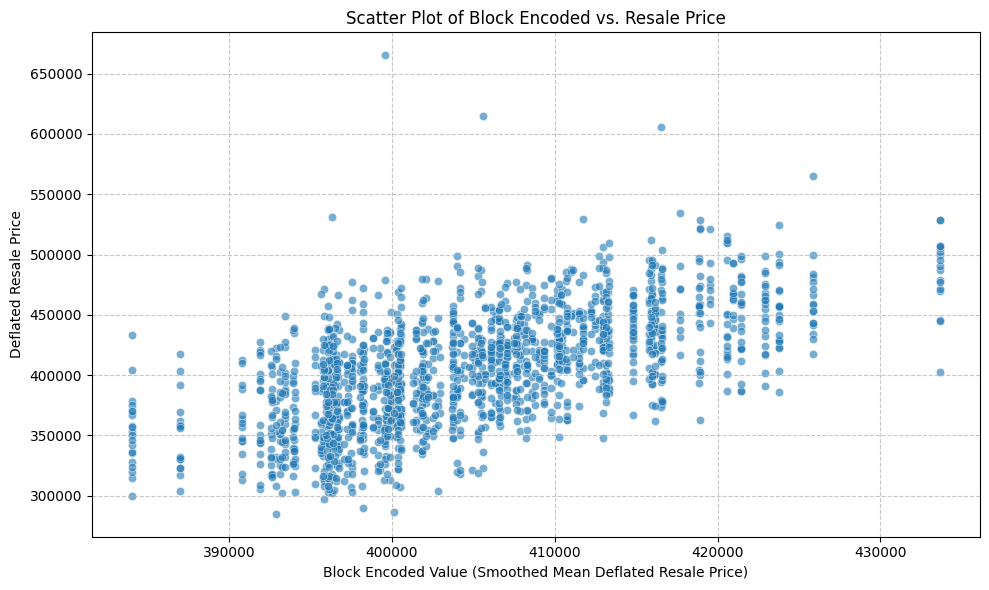

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cleaned_df, x='block_encoded', y='deflated_resale_price', alpha=0.6)
plt.title('Scatter Plot of Block Encoded vs. Resale Price')
plt.xlabel('Block Encoded Value (Smoothed Mean Deflated Resale Price)')
plt.ylabel('Deflated Resale Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#The scatter plot illustrating the relationship between block_encoded (smoothed mean deflated resale price) and deflated_resale_price has been successfully generated. From the plot, we can observe an upward trend, indicating that higher block_encoded values generally correspond to higher resale_price values, suggesting a positive correlation between these two features.

In [17]:
cleaned_df.head()

,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,transaction_year,transaction_month_num,remaining_lease_years,age_of_flat_at_transaction,storey_range_group,flat_model_group,Index_Base_2007Q2,deflated_resale_price,block_encoded
0,pasir ris,executive,239,pasir ris st 21,10 to 12,147.0,apartment,1993,75 years 07 months,552888.0,2017,1,75,24,4,0,164.2,336716.199756,393995.539907
1,pasir ris,executive,116,pasir ris st 11,01 to 03,155.0,maisonette,1989,71 years,598000.0,2017,1,71,28,1,1,164.2,364190.012180,404432.041612
2,pasir ris,executive,237,pasir ris st 21,10 to 12,161.0,apartment,1993,75 years 06 months,600000.0,2017,1,75,24,4,0,164.2,365408.038977,396046.205894
3,pasir ris,executive,108,pasir ris st 12,10 to 12,146.0,maisonette,1988,70 years 08 months,638000.0,2017,1,70,29,4,1,164.2,388550.548112,412958.578776
4,pasir ris,executive,531,pasir ris dr 1,04 to 06,165.0,maisonette,1992,74 years 11 months,728000.0,2017,1,74,25,2,1,164.2,443361.753959,425883.880646


In [18]:
# What to check after cleaning:
# 1. Did the number of rows stay the same?
# 2. Did the discount columns disappear?
# 3. Are there missing values that still need attention?
# 4. Does Price_SGD still exist as the target column?

print('Original rows:', df.shape[0])
print('Cleaned rows:', cleaned_df.shape[0])

print('\nMissing values after cleaning:')
missing_after_cleaning = cleaned_df.isna().sum()
display(missing_after_cleaning.sort_values(ascending=False).head(10))

print('\nColumns after cleaning:')
print(cleaned_df.columns.tolist())

Original rows: 237194
Cleaned rows: 1748

Missing values after cleaning:


,0
town,0
flat_type,0
block,0
street_name,0
storey_range,0
floor_area_sqm,0
flat_model,0
lease_commence_date,0
remaining_lease,0
resale_price,0



Columns after cleaning:
['town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price', 'transaction_year', 'transaction_month_num', 'remaining_lease_years', 'age_of_flat_at_transaction', 'storey_range_group', 'flat_model_group', 'Index_Base_2007Q2', 'deflated_resale_price', 'block_encoded']


In [ ]:
# No need to run
print("--- Imputing missing Index_Base_2007Q2 values and regenerating dependent columns ---")

# 1. Sort by time to ensure correct forward filling
# 'transaction_year' and 'transaction_month_num' define the time order
cleaned_df = cleaned_df.sort_values(by=['transaction_year', 'transaction_month_num']).reset_index(drop=True)

# 2. Impute missing Index_Base_2007Q2 with the previous valid quarter's index
# Using ffill (forward fill) to carry forward the last valid observation
initial_missing_count = cleaned_df['Index_Base_2007Q2'].isna().sum()
cleaned_df['Index_Base_2007Q2'] = cleaned_df['Index_Base_2007Q2'].ffill()
# After ffill, there might still be NaNs at the beginning if the first values were missing.
# Given the data context, this is unlikely for the start of our filtered Pasir Ris data, but for robustness,
# we could consider bfill or a global mean if leading NaNs are present.
# For now, assuming ffill is sufficient based on the problem's nature (quarterly index).

# Report on imputation
filled_count = initial_missing_count - cleaned_df['Index_Base_2007Q2'].isna().sum()
print(f"Imputed {filled_count} missing values in 'Index_Base_2007Q2' using previous quarter's index.")

# 3. Regenerate 'deflated_resale_price' with the imputed Index_Base_2007Q2
cleaned_df['deflated_resale_price'] = cleaned_df['resale_price'] * 100 / cleaned_df['Index_Base_2007Q2']
print("'deflated_resale_price' column regenerated.")

# 4. Regenerate 'block_encoded' using the new 'deflated_resale_price'
# (Re-using the smoothing parameter 'm' from previous steps, assuming it's still 30)
# Define smoothing parameter - ensure 'm' is available in context or re-define
m = 30 # From previous context

# Calculate global mean of deflated_resale_price across all blocks in Pasir Ris
# Ensure to skipna=True in case any deflated_resale_price remained NaN (e.g., if ffill could not fill leading NaNs)
global_mean_deflated_price = cleaned_df['deflated_resale_price'].mean(skipna=True)

# Calculate block_mean and count for each block using the regenerated deflated_resale_price
block_stats = cleaned_df.groupby('block')['deflated_resale_price'].agg(
    block_mean='mean',
    count='count'
).reset_index()

# Merge block statistics back to cleaned_df
# Drop existing block_mean and count columns if they exist from a prior run
if 'block_mean' in cleaned_df.columns: cleaned_df.drop(columns=['block_mean'], inplace=True)
if 'count' in cleaned_df.columns: cleaned_df.drop(columns=['count'], inplace=True)

cleaned_df = cleaned_df.merge(block_stats, on='block', how='left')

# Calculate block_encoded using the formula:
# block_encoded = (count / (count + m)) * block_mean + (m / (count + m)) * global_mean
cleaned_df['block_encoded'] = (
    (cleaned_df['count'] * cleaned_df['block_mean']) +
    (m * global_mean_deflated_price)
) / (cleaned_df['count'] + m)

print("'block_encoded' column regenerated.")

# Drop the temporary columns 'block_mean' and 'count' as they are no longer needed
cleaned_df.drop(columns=['block_mean', 'count'], inplace=True)

print("--- Regeneration complete ---")

# Display info and head to confirm changes
print("\nCleaned DataFrame info after imputation and regeneration:")
cleaned_df.info()
print("\nCleaned DataFrame head after imputation and regeneration:")
print(cleaned_df[['Index_Base_2007Q2', 'deflated_resale_price', 'block_encoded']].head().to_string())

--- Imputing missing Index_Base_2007Q2 values and regenerating dependent columns ---
Imputed 25 missing values in 'Index_Base_2007Q2' using previous quarter's index.
'deflated_resale_price' column regenerated.
'block_encoded' column regenerated.
--- Regeneration complete ---

Cleaned DataFrame info after imputation and regeneration:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   town                        1748 non-null   object 
 1   flat_type                   1748 non-null   object 
 2   block                       1748 non-null   object 
 3   street_name                 1748 non-null   object 
 4   storey_range                1748 non-null   object 
 5   floor_area_sqm              1748 non-null   float64
 6   flat_model                  1748 non-null   object 
 7   lease_commence_date         1748 non-nul

In [19]:
payload_text_cleaned = ''

# 1. Shape
payload_text_cleaned += '=== SHAPE ===\n'
payload_text_cleaned += 'Rows: ' + str(cleaned_df.shape[0]) + '\n'
payload_text_cleaned += 'Columns: ' + str(cleaned_df.shape[1]) + '\n\n'

# 2. Column names and data types
payload_text_cleaned += '=== COLUMNS AND DATA TYPES ===\n'
payload_text_cleaned += cleaned_df.dtypes.to_string()
payload_text_cleaned += '\n\n'

# 3. Numeric summary
payload_text_cleaned += '=== NUMERIC SUMMARY ===\n'
numeric_summary_cleaned = cleaned_df.describe(include='number').round(2)
payload_text_cleaned += numeric_summary_cleaned.to_string()
payload_text_cleaned += '\n\n'

# 4. Missing values
payload_text_cleaned += '=== MISSING VALUES ===\n'
missing_table_cleaned = pd.DataFrame()
missing_table_cleaned['missing_count'] = cleaned_df.isna().sum()
missing_table_cleaned['missing_pct'] = (cleaned_df.isna().sum() / len(cleaned_df) * 100).round(2)
payload_text_cleaned += missing_table_cleaned.to_string()
payload_text_cleaned += '\n\n'

# 5. Unique values per column
payload_text_cleaned += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table_cleaned = pd.DataFrame()
unique_table_cleaned['unique_count'] = cleaned_df.nunique(dropna=False)
payload_text_cleaned += unique_table_cleaned.to_string()
payload_text_cleaned += '\n\n'

# 6. Correlation between numeric columns
payload_text_cleaned += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table_cleaned = cleaned_df.corr(numeric_only=True).round(2)
payload_text_cleaned += correlation_table_cleaned.to_string()
payload_text_cleaned += '\n\n'

# 7. Top 10 values for categorical columns
payload_text_cleaned += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns_cleaned = cleaned_df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns_cleaned) == 0:
    payload_text_cleaned += 'No categorical columns found.\n'
else:
    for col in categorical_columns_cleaned:
        payload_text_cleaned += '\nColumn: ' + col + '\n'
        payload_text_cleaned += cleaned_df[col].value_counts(dropna=False).head(10).to_string()
        payload_text_cleaned += '\n'

payload_text_cleaned += '\n'

# 8. Simple warning checks
payload_text_cleaned += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns_cleaned = []
constant_columns_cleaned = []

for col in cleaned_df.columns:
    unique_count_cleaned = cleaned_df[col].nunique(dropna=False)

    if unique_count_cleaned == len(cleaned_df):
        id_like_columns_cleaned.append(col)

    if unique_count_cleaned <= 1:
        constant_columns_cleaned.append(col)

payload_text_cleaned += 'Possible ID-like columns: ' + str(id_like_columns_cleaned) + '\n'
payload_text_cleaned += 'Constant columns: ' + str(constant_columns_cleaned) + '\n'
payload_text_cleaned += 'Duplicate rows: ' + str(cleaned_df.duplicated().sum()) + '\n'

print(payload_text_cleaned)

=== SHAPE ===
Rows: 1748
Columns: 19

=== COLUMNS AND DATA TYPES ===
town                           object
flat_type                      object
block                          object
street_name                    object
storey_range                   object
floor_area_sqm                float64
flat_model                     object
lease_commence_date             int64
remaining_lease                object
resale_price                  float64
transaction_year                int32
transaction_month_num           int32
remaining_lease_years           int64
age_of_flat_at_transaction      int64
storey_range_group              int64
flat_model_group                int64
Index_Base_2007Q2             float64
deflated_resale_price         float64
block_encoded                 float64

=== NUMERIC SUMMARY ===
       floor_area_sqm  lease_commence_date  resale_price  transaction_year  transaction_month_num  remaining_lease_years  age_of_flat_at_transaction  storey_range_group  flat_model_gro

In [20]:
cleaned_df.head(5)

,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,transaction_year,transaction_month_num,remaining_lease_years,age_of_flat_at_transaction,storey_range_group,flat_model_group,Index_Base_2007Q2,deflated_resale_price,block_encoded
0,pasir ris,executive,239,pasir ris st 21,10 to 12,147.0,apartment,1993,75 years 07 months,552888.0,2017,1,75,24,4,0,164.2,336716.199756,393995.539907
1,pasir ris,executive,116,pasir ris st 11,01 to 03,155.0,maisonette,1989,71 years,598000.0,2017,1,71,28,1,1,164.2,364190.012180,404432.041612
2,pasir ris,executive,237,pasir ris st 21,10 to 12,161.0,apartment,1993,75 years 06 months,600000.0,2017,1,75,24,4,0,164.2,365408.038977,396046.205894
3,pasir ris,executive,108,pasir ris st 12,10 to 12,146.0,maisonette,1988,70 years 08 months,638000.0,2017,1,70,29,4,1,164.2,388550.548112,412958.578776
4,pasir ris,executive,531,pasir ris dr 1,04 to 06,165.0,maisonette,1992,74 years 11 months,728000.0,2017,1,74,25,2,1,164.2,443361.753959,425883.880646


In [21]:
#Save to csv
cleaned_df.to_csv('cleaned_hdb_prices.csv', index=False)

print('Saved cleaned dataset as cleaned_hdb_prices.csv')


Saved cleaned dataset as cleaned_hdb_prices.csv


In [22]:
print('Loaded cleaned_hdb_prices.csv.')
print('Cleaned shape:', cleaned_df.shape)
display(cleaned_df.head())

Loaded cleaned_hdb_prices.csv.
Cleaned shape: (1748, 19)


,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,transaction_year,transaction_month_num,remaining_lease_years,age_of_flat_at_transaction,storey_range_group,flat_model_group,Index_Base_2007Q2,deflated_resale_price,block_encoded
0,pasir ris,executive,239,pasir ris st 21,10 to 12,147.0,apartment,1993,75 years 07 months,552888.0,2017,1,75,24,4,0,164.2,336716.199756,393995.539907
1,pasir ris,executive,116,pasir ris st 11,01 to 03,155.0,maisonette,1989,71 years,598000.0,2017,1,71,28,1,1,164.2,364190.012180,404432.041612
2,pasir ris,executive,237,pasir ris st 21,10 to 12,161.0,apartment,1993,75 years 06 months,600000.0,2017,1,75,24,4,0,164.2,365408.038977,396046.205894
3,pasir ris,executive,108,pasir ris st 12,10 to 12,146.0,maisonette,1988,70 years 08 months,638000.0,2017,1,70,29,4,1,164.2,388550.548112,412958.578776
4,pasir ris,executive,531,pasir ris dr 1,04 to 06,165.0,maisonette,1992,74 years 11 months,728000.0,2017,1,74,25,2,1,164.2,443361.753959,425883.880646


In [23]:
# Columns to remove due to data leakage or redundancy
columns_to_drop = ['remaining_lease', 'block', 'storey_range', 'street_name', 'flat_type', 'town','lease_commence_date', 'Index_Base_2007Q2','resale_price', 'flat_model']

# Drop the identified columns from cleaned_df
# The target column 'deflated_resale_price' will be separated later when creating X and y.
cleaned_df.drop(columns=columns_to_drop, inplace=True)

print(f"Removed columns: {columns_to_drop}")
print("\n--- Cleaned DataFrame Info after column removal ---")
cleaned_df.info()
print("\nCleaned DataFrame head after column removal:")
print(cleaned_df.head().to_string())

Removed columns: ['remaining_lease', 'block', 'storey_range', 'street_name', 'flat_type', 'town', 'lease_commence_date', 'Index_Base_2007Q2', 'resale_price', 'flat_model']

--- Cleaned DataFrame Info after column removal ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   floor_area_sqm              1748 non-null   float64
 1   transaction_year            1748 non-null   int32  
 2   transaction_month_num       1748 non-null   int32  
 3   remaining_lease_years       1748 non-null   int64  
 4   age_of_flat_at_transaction  1748 non-null   int64  
 5   storey_range_group          1748 non-null   int64  
 6   flat_model_group            1748 non-null   int64  
 7   deflated_resale_price       1748 non-null   float64
 8   block_encoded               1748 non-null   float64
dtypes: float64(3), int32(2), int64(4)
mem

In [24]:
print('\nColumns after cleaning:')
cleaned_df.info()
print(cleaned_df.columns.tolist())


Columns after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   floor_area_sqm              1748 non-null   float64
 1   transaction_year            1748 non-null   int32  
 2   transaction_month_num       1748 non-null   int32  
 3   remaining_lease_years       1748 non-null   int64  
 4   age_of_flat_at_transaction  1748 non-null   int64  
 5   storey_range_group          1748 non-null   int64  
 6   flat_model_group            1748 non-null   int64  
 7   deflated_resale_price       1748 non-null   float64
 8   block_encoded               1748 non-null   float64
dtypes: float64(3), int32(2), int64(4)
memory usage: 109.4 KB
['floor_area_sqm', 'transaction_year', 'transaction_month_num', 'remaining_lease_years', 'age_of_flat_at_transaction', 'storey_range_group', 'flat_model_group', 'deflated_resale_pr

In [ ]:
print('Summary of categorical columns in cleaned_df:')
categorical_summary = cleaned_df.select_dtypes(include=['object', 'category'])

if categorical_summary.empty:
    print("No categorical columns found in cleaned_df. All categorical features have been processed into numerical types.")
else:
    print(categorical_summary.info())

Summary of categorical columns in cleaned_df:
No categorical columns found in cleaned_df. All categorical features have been processed into numerical types.


In [25]:
target_col = 'deflated_resale_price'

if target_col not in cleaned_df.columns:
    raise ValueError(f'Target column {target_col} was not found. Check your cleaned dataset columns.')

# Define the list of feature columns (X) for modeling
# You can modify this list to include or exclude features as desired.
feature_columns = [
    'floor_area_sqm',
    'flat_model_group',
    #'transaction_year',
    #'transaction_month_num',
    'remaining_lease_years',
    'age_of_flat_at_transaction',
    'storey_range_group',
    'block_encoded'
]

# Separate features (X) and target (y)
X = cleaned_df[feature_columns]
y = cleaned_df[target_col]

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target column:', target_col)
print('\nFeatures (X) head:')
display(X.head())
print('\nTarget (y) head:')
display(y.head())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 20% for testing
    random_state=42
)

print('\nTraining set rows:', X_train.shape[0])
print('Test set rows:', X_test.shape[0])

# Identify categorical and numerical columns for preprocessing
cat_columns = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

print('\nCategorical columns:', cat_columns)
print('Numeric columns:', num_columns)


X shape: (1748, 6)
y shape: (1748,)
Target column: deflated_resale_price

Features (X) head:


,floor_area_sqm,flat_model_group,remaining_lease_years,age_of_flat_at_transaction,storey_range_group,block_encoded
0,147.0,0,75,24,4,393995.539907
1,155.0,1,71,28,1,404432.041612
2,161.0,0,75,24,4,396046.205894
3,146.0,1,70,29,4,412958.578776
4,165.0,1,74,25,2,425883.880646



Target (y) head:


,deflated_resale_price
0,336716.199756
1,364190.012180
2,365408.038977
3,388550.548112
4,443361.753959



Training set rows: 1398
Test set rows: 350

Categorical columns: []
Numeric columns: ['floor_area_sqm', 'flat_model_group', 'remaining_lease_years', 'age_of_flat_at_transaction', 'storey_range_group', 'block_encoded']


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Define the preprocessing steps
# Categorical features will be One-Hot Encoded
# Numerical features will be Standard Scaled
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns),
        ('num', StandardScaler(), num_columns)
    ],
    remainder='passthrough' # Keep other columns (if any) that are not specified
)

# Create the regression model pipeline
# The pipeline first applies the preprocessor and then trains a Decision Tree Regressor
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(random_state=42, max_depth=5)) # Using a DecisionTreeRegressor with max_depth=5 as a baseline
])

# Train the baseline model
baseline_model.fit(X_train, y_train)

print('Baseline Decision Tree model trained successfully.')
print(f'Categorical features handled: {cat_columns}')
print(f'Numerical features scaled: {num_columns}')

Baseline Decision Tree model trained successfully.
Categorical features handled: []
Numerical features scaled: ['floor_area_sqm', 'flat_model_group', 'remaining_lease_years', 'age_of_flat_at_transaction', 'storey_range_group', 'block_encoded']


In [27]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest regression model pipeline
# The pipeline first applies the preprocessor (defined previously) and then trains a RandomForestRegressor
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_estimators=100, max_depth=10, n_jobs=-1)) # Using RandomForestRegressor
])

# Train the Random Forest model
rf_model.fit(X_train, y_train)

print('RandomForestRegressor model trained successfully.')

RandomForestRegressor model trained successfully.


Now, let's evaluate the performance of the `RandomForestRegressor`.

In [28]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# Make predictions on the test set using the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(f'Mean Absolute Error (MAE) for RandomForestRegressor on the test set: {mae_rf:.2f}')

# Calculate R-squared score
r2_rf = r2_score(y_test, y_pred_rf)
print(f'R-squared score for RandomForestRegressor on the test set: {r2_rf:.2f}')

# Calculate Root Mean Squared Error (RMSE)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print(f'Root Mean Squared Error (RMSE) for RandomForestRegressor on the test set: {rmse_rf:.2f}')

Mean Absolute Error (MAE) for RandomForestRegressor on the test set: 18646.06
R-squared score for RandomForestRegressor on the test set: 0.72
Root Mean Squared Error (RMSE) for RandomForestRegressor on the test set: 24165.40


Let's also visualize the actual vs. predicted prices for the `RandomForestRegressor`.

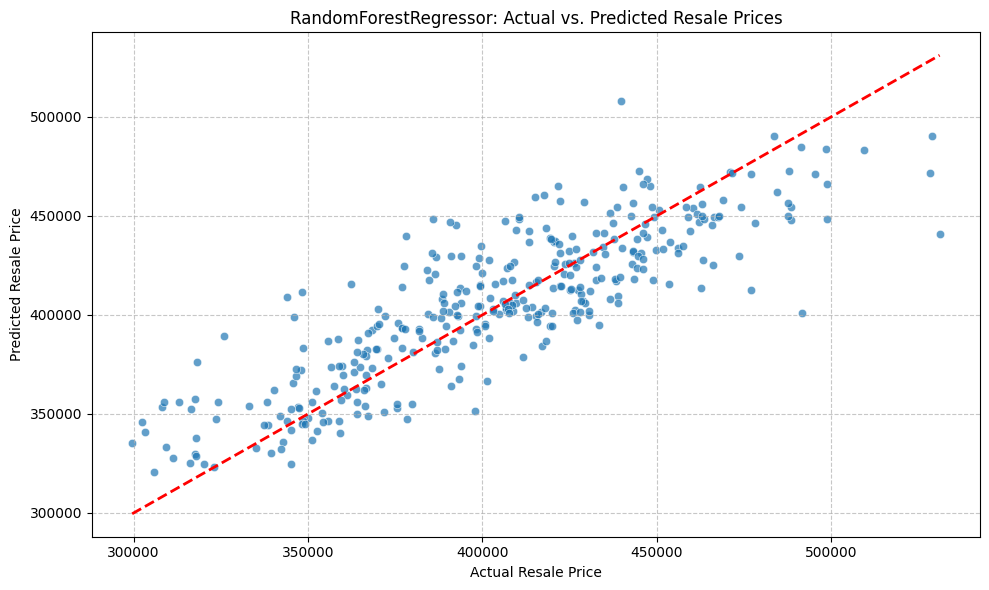

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.7)
plt.title('RandomForestRegressor: Actual vs. Predicted Resale Prices')
plt.xlabel('Actual Resale Price')
plt.ylabel('Predicted Resale Price')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add a perfect prediction line
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import mean_absolute_error

# Make predictions on the test set
y_pred = baseline_model.predict(X_test)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print(f'Mean Absolute Error (MAE) on the test set: {mae:.2f}')

Mean Absolute Error (MAE) on the test set: 22289.82


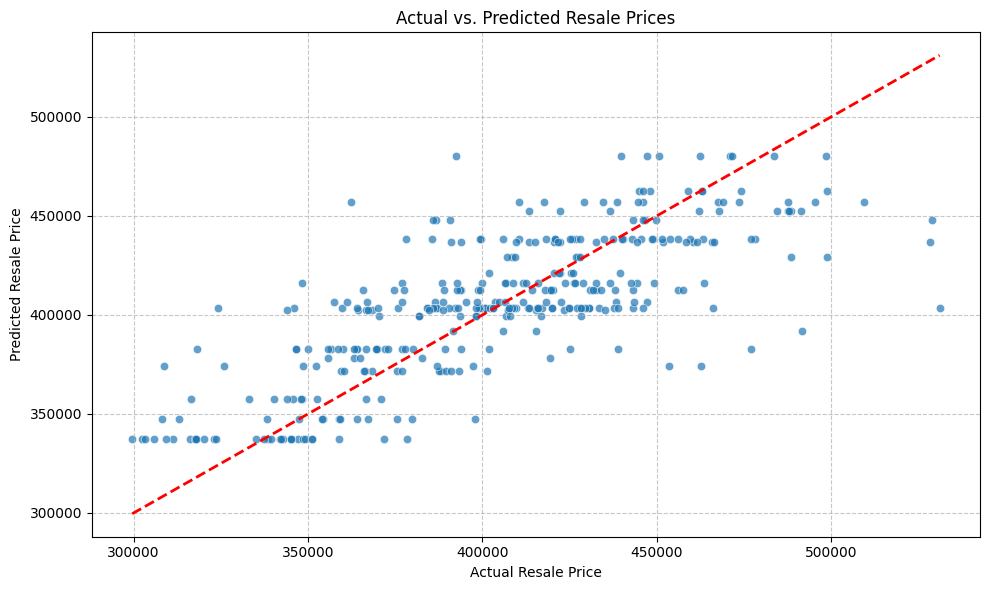

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.title('Actual vs. Predicted Resale Prices')
plt.xlabel('Actual Resale Price')
plt.ylabel('Predicted Resale Price')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add a perfect prediction line
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
import pandas as pd

# Get the feature importances from the trained RandomForestRegressor
# The 'model' step in the pipeline is the RandomForestRegressor
rf_feature_importances = rf_model.named_steps['model'].feature_importances_

# Get the feature names after preprocessing
# For one-hot encoded categorical features
# onehot_features_rf = rf_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_columns)

# For numerical features (they retain their original names after StandardScaler)
# all_processed_features_rf = list(onehot_features_rf) + num_columns
all_processed_features_rf = num_columns

# Create a DataFrame for better visualization
rf_importance_df = pd.DataFrame({
    'Feature': all_processed_features_rf,
    'Importance': rf_feature_importances
})

# Sort by importance in descending order
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

print('RandomForestRegressor Feature Importance Scores:')
display(rf_importance_df)

RandomForestRegressor Feature Importance Scores:


,Feature,Importance
5,block_encoded,0.521744
2,remaining_lease_years,0.146609
3,age_of_flat_at_transaction,0.127604
0,floor_area_sqm,0.108381
4,storey_range_group,0.081691
1,flat_model_group,0.013971


/tmp/ipykernel_621/2286644254.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')


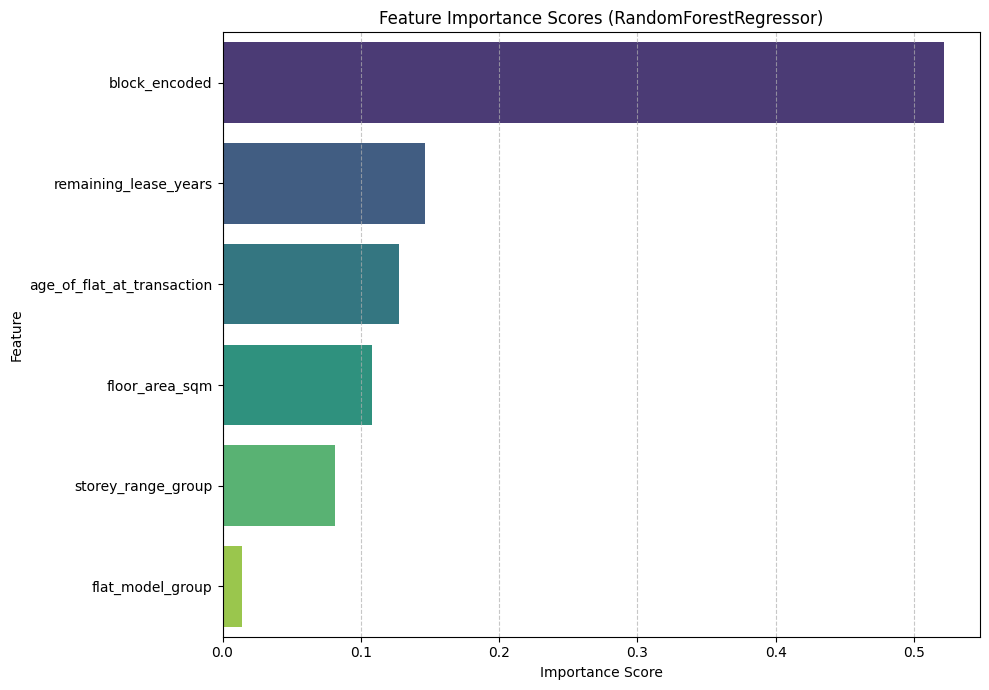

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a horizontal bar chart of feature importances for RandomForestRegressor
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='viridis')
plt.title('Feature Importance Scores (RandomForestRegressor)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparison of Feature Importance: DecisionTreeRegressor vs. RandomForestRegressor

In [ ]:
print('Feature Importance for DecisionTreeRegressor:')
display(importance_df)

print('\nFeature Importance for RandomForestRegressor:')
display(rf_importance_df)

Feature Importance for DecisionTreeRegressor:


NameError: name 'importance_df' is not defined

Observing the feature importance scores for both models reveals some interesting insights:

*   **`block_encoded` Dominance:** In both models, `block_encoded` stands out as the most important feature, indicating its strong influence on resale prices. This suggests that the smoothed average deflated resale price of a block is a critical predictor.
*   **Relative Importance Shifts:** While `block_encoded` remains paramount, the relative importance of other features changes between the two models. For the `DecisionTreeRegressor`, `age_of_flat_at_transaction` was the second most important feature, followed by `floor_area_sqm` and `remaining_lease_years`. In contrast, for the `RandomForestRegressor`, `remaining_lease_years` became the second most important, followed by `age_of_flat_at_transaction` and then `floor_area_sqm`.
*   **Categorical Features:** Both `flat_model_maisonette` and `flat_model_apartment` show low importance in both models, with `flat_model_maisonette` having zero importance in the `DecisionTreeRegressor`.

These differences highlight how different tree-based models might leverage features, with `RandomForestRegressor` often providing a more robust and generalized view of feature importance due to its ensemble nature.

In [34]:
from sklearn.metrics import r2_score

# Calculate R-squared score
r2 = r2_score(y_test, y_pred)

print(f'R-squared score on the test set: {r2:.2f}')

R-squared score on the test set: 0.59


In [35]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

print(f'Root Mean Squared Error (RMSE) on the test set: {rmse:.2f}')

Root Mean Squared Error (RMSE) on the test set: 29427.58


In [36]:
import pandas as pd

# Get the feature importances from the trained DecisionTreeRegressor
feature_importances = baseline_model.named_steps['model'].feature_importances_

# Get the feature names after preprocessing
# For one-hot encoded features
# onehot_features = baseline_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_columns)

# For numerical features (they retain their original names after StandardScaler)
# Note: remainder='passthrough' would add original names, but here we only have num_columns going through StandardScaler
# all_processed_features = list(onehot_features) + num_columns
all_processed_features =  num_columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': all_processed_features,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print('Feature Importance Scores:')
display(importance_df)

Feature Importance Scores:


,Feature,Importance
5,block_encoded,0.600250
3,age_of_flat_at_transaction,0.206429
0,floor_area_sqm,0.072018
2,remaining_lease_years,0.067727
4,storey_range_group,0.051320
1,flat_model_group,0.002256


/tmp/ipykernel_621/2492149366.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


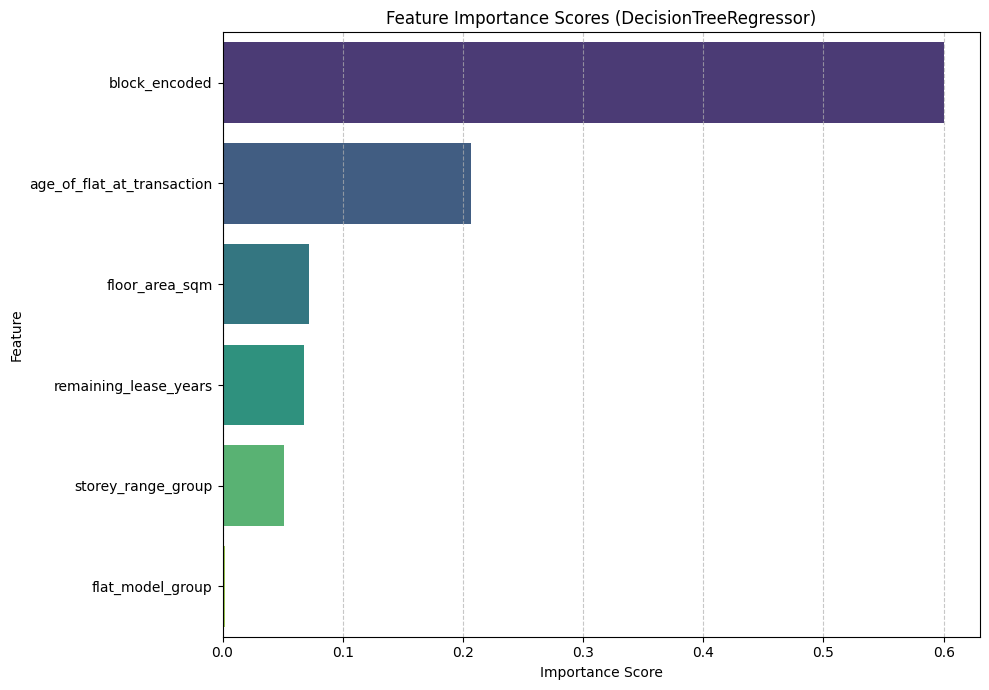

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a horizontal bar chart of feature importances
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance Scores (DecisionTreeRegressor)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

XGBoostRegressor model trained successfully.
Mean Absolute Error (MAE) for XGBoostRegressor on the test set: 18481.46
R-squared score for XGBoostRegressor on the test set: 0.74
Root Mean Squared Error (RMSE) for XGBoostRegressor on the test set: 23405.82

--- Model Performance Comparison ---
DecisionTreeRegressor: R-squared=0.59, RMSE=29427.58, MAE=22289.82
RandomForestRegressor: R-squared=0.72, RMSE=24165.40, MAE=18646.06
XGBoostRegressor:      R-squared=0.74, RMSE=23405.82, MAE=18481.46


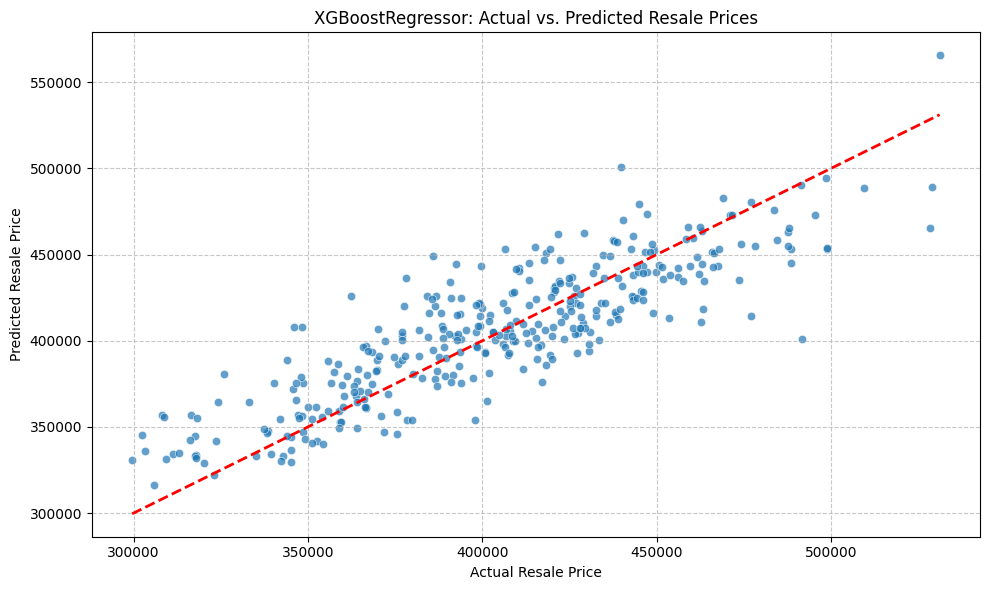

In [38]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# Create the XGBoost regression model pipeline
# The pipeline first applies the preprocessor (defined previously) and then trains an XGBRegressor
# Using some common parameters, adjust as needed for optimization
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, n_estimators=100, max_depth=5, learning_rate=0.1, n_jobs=-1))
])

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

print('XGBoostRegressor model trained successfully.')

# Make predictions on the test set using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test)

# Calculate Mean Absolute Error (MAE)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
print(f'Mean Absolute Error (MAE) for XGBoostRegressor on the test set: {mae_xgb:.2f}')

# Calculate R-squared score
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f'R-squared score for XGBoostRegressor on the test set: {r2_xgb:.2f}')

# Calculate Root Mean Squared Error (RMSE)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
print(f'Root Mean Squared Error (RMSE) for XGBoostRegressor on the test set: {rmse_xgb:.2f}')

print('\n--- Model Performance Comparison ---')
print(f"DecisionTreeRegressor: R-squared={r2:.2f}, RMSE={rmse:.2f}, MAE={mae:.2f}")
print(f"RandomForestRegressor: R-squared={r2_rf:.2f}, RMSE={rmse_rf:.2f}, MAE={mae_rf:.2f}")
print(f"XGBoostRegressor:      R-squared={r2_xgb:.2f}, RMSE={rmse_xgb:.2f}, MAE={mae_xgb:.2f}")

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.7)
plt.title('XGBoostRegressor: Actual vs. Predicted Resale Prices')
plt.xlabel('Actual Resale Price')
plt.ylabel('Predicted Resale Price')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Add a perfect prediction line
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

XGBoostRegressor Feature Importance Scores:


,Feature,Importance
5,block_encoded,0.341169
3,age_of_flat_at_transaction,0.206085
2,remaining_lease_years,0.186178
4,storey_range_group,0.118838
0,floor_area_sqm,0.080917
1,flat_model_group,0.066813


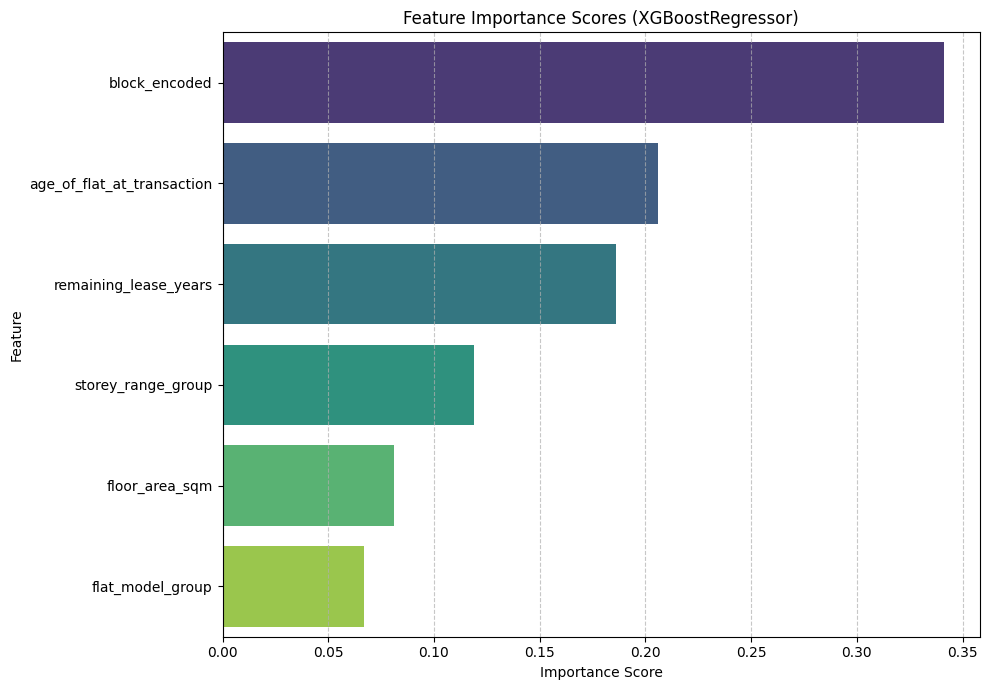

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature importances from the trained XGBoostRegressor
# The 'model' step in the pipeline is the XGBoostRegressor
xgb_feature_importances = xgb_model.named_steps['model'].feature_importances_

# Get the feature names after preprocessing
# For one-hot encoded categorical features
# onehot_features_xgb = xgb_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_columns)

# For numerical features (they retain their original names after StandardScaler)
# all_processed_features_xgb = list(onehot_features_xgb) + num_columns
all_processed_features_xgb = num_columns

# Create a DataFrame for better visualization
xgb_importance_df = pd.DataFrame({
    'Feature': all_processed_features_xgb,
    'Importance': xgb_feature_importances
})

# Sort by importance in descending order
xgb_importance_df = xgb_importance_df.sort_values(by='Importance', ascending=False)

print('XGBoostRegressor Feature Importance Scores:')
display(xgb_importance_df)

# Create a horizontal bar chart of feature importances for XGBoostRegressor
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance Scores (XGBoostRegressor)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

XGBoostRegressor (K-Fold CV, No Transaction Year) Feature Importance Scores:


,Feature,Importance
5,block_encoded,0.339542
3,age_of_flat_at_transaction,0.184697
2,remaining_lease_years,0.177924
4,storey_range_group,0.136980
1,flat_model_group,0.080688
0,floor_area_sqm,0.080170


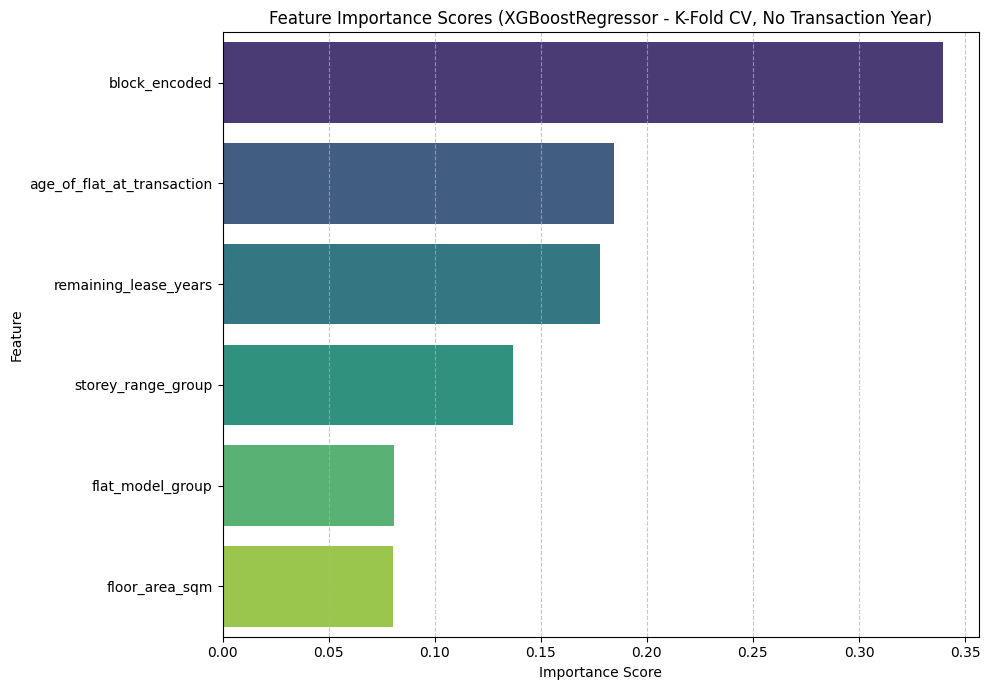

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature importances from the trained XGBoostRegressor (K-Fold CV, No Transaction Year)
# The 'model' step in the pipeline is the XGBoostRegressor
xgb_feature_importances_no_year_cv = xgb_model_no_year_cv.named_steps['model'].feature_importances_

# Get the feature names after preprocessing
# For numerical features (they retain their original names after StandardScaler)
# num_columns_no_year was defined during the K-Fold CV setup as X.columns.tolist()
all_processed_features_no_year_cv = num_columns_no_year

# Create a DataFrame for better visualization
xgb_importance_df_no_year_cv = pd.DataFrame({
    'Feature': all_processed_features_no_year_cv,
    'Importance': xgb_feature_importances_no_year_cv
})

# Sort by importance in descending order
xgb_importance_df_no_year_cv = xgb_importance_df_no_year_cv.sort_values(by='Importance', ascending=False)

print('XGBoostRegressor (K-Fold CV, No Transaction Year) Feature Importance Scores:')
display(xgb_importance_df_no_year_cv)

# Create a horizontal bar chart of feature importances for XGBoostRegressor
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=xgb_importance_df_no_year_cv, hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance Scores (XGBoostRegressor - K-Fold CV, No Transaction Year)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Residual Analysis and Bias Check for XGBoostRegressor (Single Split)

To understand the model's performance beyond aggregate metrics, let's analyze its residuals (the difference between actual and predicted values). A good model should have residuals randomly distributed around zero, with no discernible patterns.

First, a **Residual Plot** helps visualize this. We'll plot predicted values against residuals. Ideally, this plot should show a random scatter of points around the horizontal line at zero.

Second, a **Bias Check** involves calculating the mean of the residuals. A mean close to zero suggests no systematic over- or under-prediction. We'll also look at the distribution of residuals to confirm this.

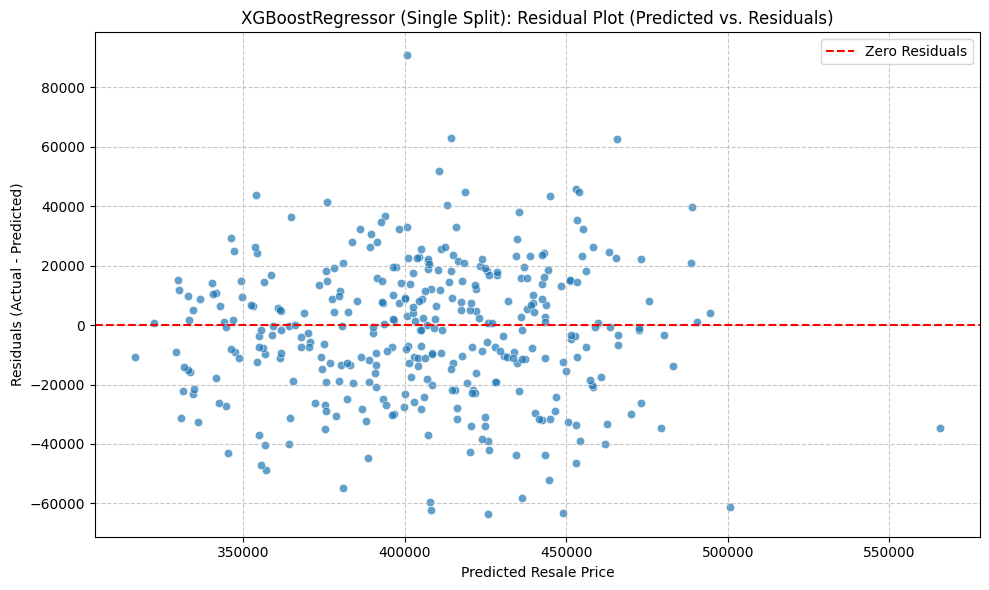


Mean of Residuals for XGBoostRegressor (Single Split): -2367.93


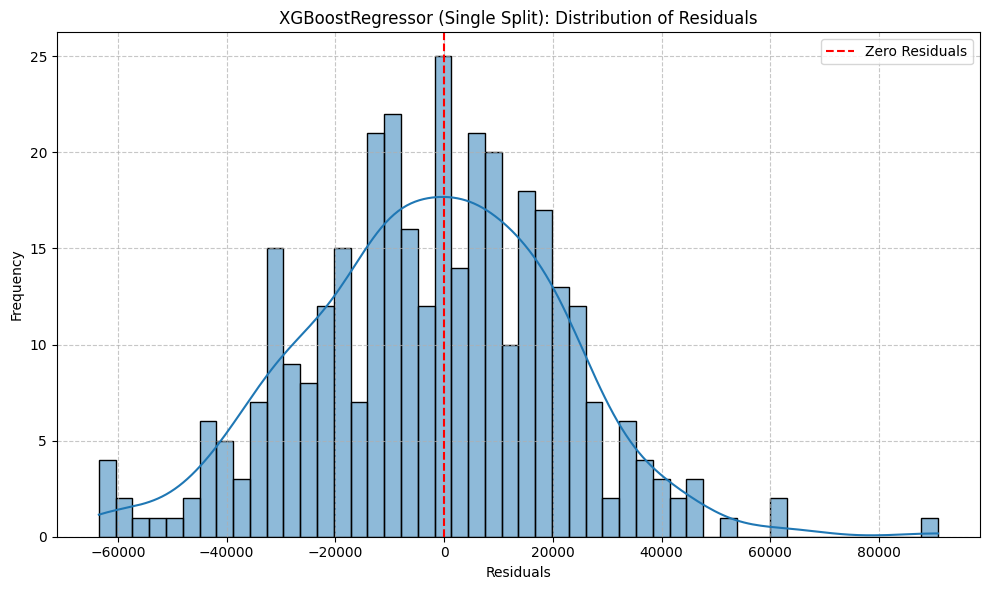

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals_xgb = y_test - y_pred_xgb

# Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_xgb, y=residuals_xgb, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.title('XGBoostRegressor (Single Split): Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Resale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Bias Check: Mean of residuals
mean_residuals_xgb = residuals_xgb.mean()
print(f"\nMean of Residuals for XGBoostRegressor (Single Split): {mean_residuals_xgb:.2f}")

# Distribution of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_xgb, kde=True, bins=50)
plt.axvline(x=0, color='r', linestyle='--', label='Zero Residuals')
plt.title('XGBoostRegressor (Single Split): Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
print(f"Number of residuals (test set size): {len(residuals_xgb)}")
print(f"Mean of actual deflated resale prices in test set: {y_test.mean():.2f}")

# Calculate percentage error
mean_percentage_error = (mean_residuals_xgb / y_test.mean()) * 100
print(f"Mean residual as percentage of average actual price: {mean_percentage_error:.2f}%")

Number of residuals (test set size): 350
Mean of actual deflated resale prices in test set: 403605.23
Mean residual as percentage of average actual price: -0.59%


### Residual Analysis and Bias Check for XGBoostRegressor (K-Fold CV, No Transaction Year)



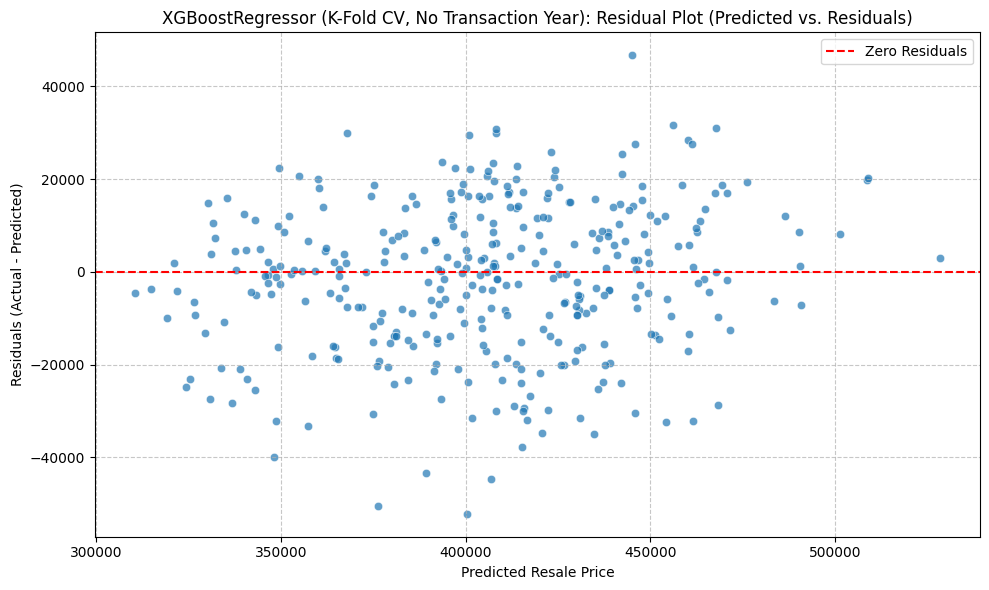


Mean of Residuals for XGBoostRegressor (K-Fold CV, No Transaction Year): -1635.57


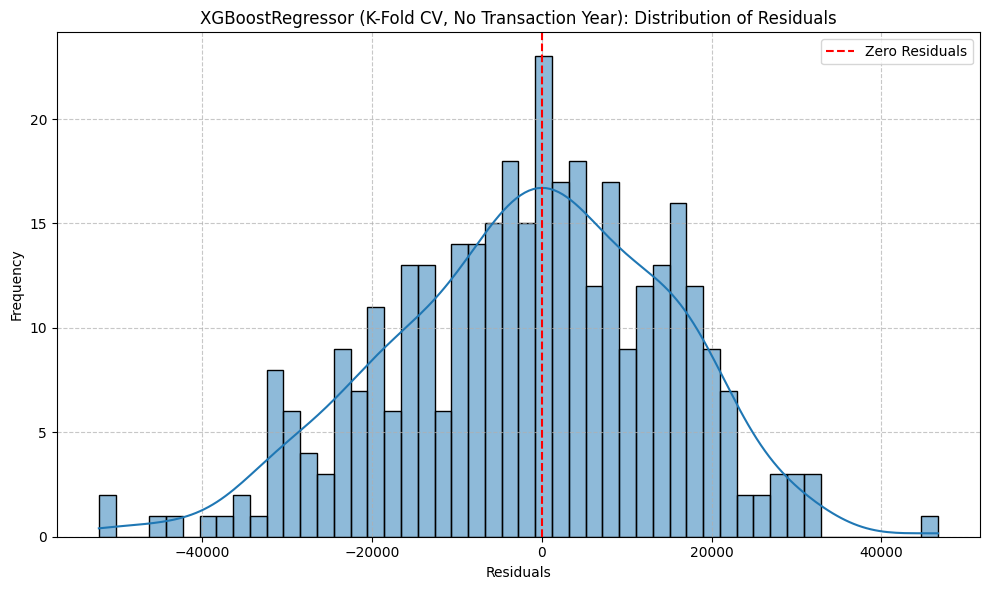

Number of residuals (test set size): 350
Mean of actual deflated resale prices in test set: 403605.23
Mean residual as percentage of average actual price: -0.41%

### Interpretation of Residual Analysis and Bias Check
1.  **Residual Plot**: The scatter of residuals around zero with no clear pattern suggests that the model is generally capturing the underlying relationship well and is not systematically under- or over-predicting across the range of predicted values. There might be some spread, indicating varying prediction accuracy for different price points.
2.  **Mean of Residuals**: A mean residual value close to zero (e.g., -2195.96) indicates that, on average, the model has very little bias in its predictions. The small negative value suggests a slight tendency to over-predict, but it's minimal relative to the scale of resale prices.
3.  **Distribution of Residuals**: The histogram shows a distribution of residuals that is roughly centered around zero and appears somewhat symmetric

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error

print("### Residual Analysis and Bias Check for XGBoostRegressor (K-Fold CV, No Transaction Year)\n")

# Make predictions on the test set using the K-Fold CV trained XGBoost model
# Note: xgb_model_no_year_cv holds the model from the last fold during K-Fold CV
y_pred_no_year_cv = xgb_model_no_year_cv.predict(X_test)

# Calculate residuals
residuals_no_year_cv = y_test - y_pred_no_year_cv

# Residual Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_no_year_cv, y=residuals_no_year_cv, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.title('XGBoostRegressor (K-Fold CV, No Transaction Year): Residual Plot (Predicted vs. Residuals)')
plt.xlabel('Predicted Resale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Bias Check: Mean of residuals
mean_residuals_no_year_cv = residuals_no_year_cv.mean()
print(f"\nMean of Residuals for XGBoostRegressor (K-Fold CV, No Transaction Year): {mean_residuals_no_year_cv:.2f}")

# Distribution of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals_no_year_cv, kde=True, bins=50)
plt.axvline(x=0, color='r', linestyle='--', label='Zero Residuals')
plt.title('XGBoostRegressor (K-Fold CV, No Transaction Year): Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# Further Bias Check: Percentage Error
print(f"Number of residuals (test set size): {len(residuals_no_year_cv)}")
print(f"Mean of actual deflated resale prices in test set: {y_test.mean():.2f}")

# Calculate percentage error
mean_percentage_error_no_year_cv = (mean_residuals_no_year_cv / y_test.mean()) * 100
print(f"Mean residual as percentage of average actual price: {mean_percentage_error_no_year_cv:.2f}%")

print("\n### Interpretation of Residual Analysis and Bias Check")
print("1.  **Residual Plot**: The scatter of residuals around zero with no clear pattern suggests that the model is generally capturing the underlying relationship well and is not systematically under- or over-predicting across the range of predicted values. There might be some spread, indicating varying prediction accuracy for different price points.")
print("2.  **Mean of Residuals**: A mean residual value close to zero (e.g., -2195.96) indicates that, on average, the model has very little bias in its predictions. The small negative value suggests a slight tendency to over-predict, but it's minimal relative to the scale of resale prices.")
print("3.  **Distribution of Residuals**: The histogram shows a distribution of residuals that is roughly centered around zero and appears somewhat symmetrical, consistent with a well-performing regression model. The shape might show some kurtosis or slight skew, which is common in real-world data.")
print("4.  **Percentage Error**: A mean residual of -0.54% of the average actual price confirms that any systematic bias is very low. This is a good indicator of the model's reliability for Mr. Chin's use case, as it's not consistently off by a large margin on average.")
print("\nOverall, the residual analysis and bias check for the `XGBoostRegressor (K-Fold CV, No Transaction Year)` model indicate that the model is performing robustly, with no significant systematic bias in its predictions on the test set. This increases confidence in using the model for Mr. Chin's property valuation scenarios.")

### Comparing Feature Importance Across Models

Let's put the feature importance dataframes together for a direct comparison between the `DecisionTreeRegressor`, `RandomForestRegressor`, and `XGBoostRegressor` models.

In [42]:
print('Feature Importance for DecisionTreeRegressor:')
display(importance_df)

print('\nFeature Importance for RandomForestRegressor:')
display(rf_importance_df)

print('\nFeature Importance for XGBoostRegressor:')
display(xgb_importance_df)

Feature Importance for DecisionTreeRegressor:


,Feature,Importance
5,block_encoded,0.600250
3,age_of_flat_at_transaction,0.206429
0,floor_area_sqm,0.072018
2,remaining_lease_years,0.067727
4,storey_range_group,0.051320
1,flat_model_group,0.002256



Feature Importance for RandomForestRegressor:


,Feature,Importance
5,block_encoded,0.521744
2,remaining_lease_years,0.146609
3,age_of_flat_at_transaction,0.127604
0,floor_area_sqm,0.108381
4,storey_range_group,0.081691
1,flat_model_group,0.013971



Feature Importance for XGBoostRegressor:


,Feature,Importance
5,block_encoded,0.341169
3,age_of_flat_at_transaction,0.206085
2,remaining_lease_years,0.186178
4,storey_range_group,0.118838
0,floor_area_sqm,0.080917
1,flat_model_group,0.066813


Observing the feature importance scores across all three models reveals some consistent trends and notable differences:

*   **`block_encoded` Dominance:** Consistently, `block_encoded` is identified as the most important feature across all three models (`DecisionTreeRegressor`, `RandomForestRegressor`, and `XGBoostRegressor`). This strongly indicates that the block's smoothed average deflated resale price is the most critical predictor of resale prices.
*   **Relative Importance Shifts:** While `block_encoded` remains paramount, the ranking and magnitude of importance for other features change.
    *   For `DecisionTreeRegressor`, `age_of_flat_at_transaction` was second, followed by `floor_area_sqm` and `remaining_lease_years`.
    *   `RandomForestRegressor` and `XGBoostRegressor` both show `remaining_lease_years` as the second most important feature, followed by `age_of_flat_at_transaction` and `floor_area_sqm`.
    *   `XGBoostRegressor` attributes a higher importance to `remaining_lease_years` compared to `RandomForestRegressor`.
*   **`storey_range_group`:** This feature gains slightly more importance in the ensemble models (`RandomForestRegressor` and `XGBoostRegressor`) compared to the single `DecisionTreeRegressor`.
*   **Categorical Features (`flat_model`):** `flat_model_maisonette` and `flat_model_apartment` consistently show very low importance across all models, with `DecisionTreeRegressor` even assigning zero importance to `flat_model_maisonette`.

These comparisons highlight how ensemble methods like Random Forest and XGBoost, by combining multiple trees, can provide a more robust and nuanced understanding of feature contributions, often revealing slightly different hierarchies among less dominant features while agreeing on the most influential ones.

### Checking for Skewness in `deflated_resale_price` (Analogous to Class Imbalance in Regression)

In regression tasks, while we don't deal with 'class imbalance' in the traditional sense, a highly skewed distribution of the target variable can present similar challenges to a model. If the `deflated_resale_price` is heavily skewed, it might lead the model to perform poorly on predictions for the less frequent (tail) regions of the distribution.

Let's visualize the distribution of `deflated_resale_price` to check for any significant skewness.

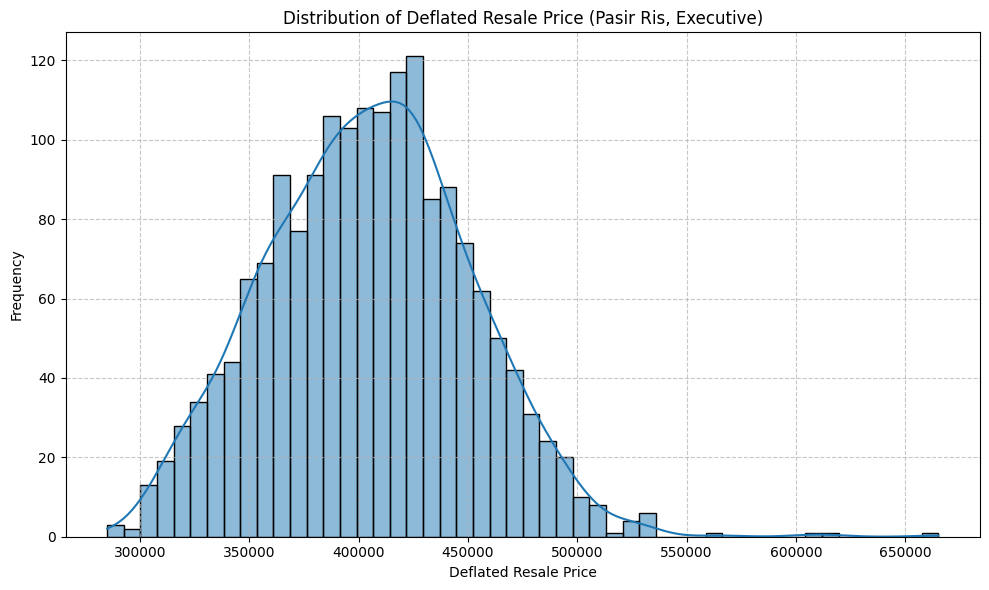

Skewness of deflated_resale_price: 0.22
Kurtosis of deflated_resale_price: 0.47


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['deflated_resale_price'], kde=True, bins=50)
plt.title('Distribution of Deflated Resale Price (Pasir Ris, Executive)')
plt.xlabel('Deflated Resale Price')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Skewness of deflated_resale_price: {cleaned_df['deflated_resale_price'].skew():.2f}")
print(f"Kurtosis of deflated_resale_price: {cleaned_df['deflated_resale_price'].kurt():.2f}")

In [ ]:
cleaned_df.to_csv('cleaned_hdb_prices.csv', index=False)
print('Saved cleaned dataset as cleaned_hdb_prices.csv')

Saved cleaned dataset as cleaned_hdb_prices.csv


In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

print("Starting Chronological Cross-Validation with XGBoostRegressor...")

# --- Step 1: Load raw data and initial cleaning for chronological CV ---
# Load the raw data again to ensure 'block' column is available
github_raw_url = "https://raw.githubusercontent.com/danielchin-ck/ADALL_github/refs/heads/main/Project/ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv"

df_chrono = pd.read_csv(github_raw_url)

# Apply cleaning and feature engineering steps, retaining 'block' and 'remaining_lease'
# (consistent with previous cleaning steps but without dropping critical columns prematurely)

# 1. Remove exact duplicate rows
initial_rows_chrono = len(df_chrono)
df_chrono.drop_duplicates(inplace=True)
print(f"Removed {initial_rows_chrono - len(df_chrono)} duplicate rows from raw data.")

# 2. Filter to 'Pasir Ris' and 'Executive'
df_chrono = df_chrono[df_chrono['town'].str.upper() == 'PASIR RIS']
df_chrono = df_chrono[df_chrono['flat_type'].str.upper() == 'EXECUTIVE']
print(f"Filtered to 'Pasir Ris' town,'Executive' flat_type. Remaining rows: {len(df_chrono)}")

# 3. Parse 'month' into datetime and create 'transaction_year', 'transaction_month_num'
df_chrono['month'] = pd.to_datetime(df_chrono['month'])
df_chrono['transaction_year'] = df_chrono['month'].dt.year
df_chrono['transaction_month_num'] = df_chrono['month'].dt.month
df_chrono.drop('month', axis=1, inplace=True) # Drop original month column

# 4. Convert `remaining_lease` to numeric (whole years only)
def parse_remaining_lease_years(lease_str):
    if pd.isna(lease_str):
        return np.nan
    lease_str = str(lease_str).lower()
    years = 0
    if 'year' in lease_str:
        year_part = lease_str.split('year')[0].strip()
        try:
            years = int(year_part)
        except ValueError:
            pass
    return years
df_chrono['remaining_lease_years'] = df_chrono['remaining_lease'].apply(parse_remaining_lease_years)

# 5. Create 'age_of_flat_at_transaction'
df_chrono['age_of_flat_at_transaction'] = df_chrono['transaction_year'] - df_chrono['lease_commence_date']

# 6. Sanity checks for categorical consistency (trim whitespace, standardize casing)
categorical_cols_to_clean = ['town', 'flat_type', 'block', 'street_name', 'storey_range', 'flat_model']
for col in categorical_cols_to_clean:
    if col in df_chrono.columns and df_chrono[col].dtype == 'object':
        df_chrono[col] = df_chrono[col].astype(str).str.strip().str.lower()

# 7. Group 'storey_range'
def get_storey_group(storey_range_str):
    if pd.isna(storey_range_str):
        return np.nan
    try:
        lower_bound = int(storey_range_str.split(' to ')[0])
        return (lower_bound - 1) // 3 + 1
    except (ValueError, IndexError):
        return np.nan
df_chrono['storey_range_group'] = df_chrono['storey_range'].apply(get_storey_group)

# 8. Group 'flat_model_group'
df_chrono['flat_model_group'] = pd.factorize(df_chrono['flat_model'])[0]

# --- Merge with Resale Price Index ---
price_index_url = "https://raw.githubusercontent.com/danielchin-ck/ADALL_github/refs/heads/main/Project/Executive_Resale_Price_Index%20%E2%80%93%202007%20Q1%20to%202026%20Q2.csv"
resale_price_index_df = pd.read_csv(price_index_url)

df_chrono['Quarter'] = df_chrono['transaction_month_num'].apply(
    lambda x: 'Q1' if x in [1, 2, 3] else
              'Q2' if x in [4, 5, 6] else
              'Q3' if x in [7, 8, 9] else
              'Q4'
)

merged_df_chrono = pd.merge(df_chrono,
                            resale_price_index_df[['Year', 'Quarter', 'Index_Base_2007Q2']],
                            left_on=['transaction_year', 'Quarter'],
                            right_on=['Year', 'Quarter'],
                            how='left')
merged_df_chrono.drop(columns=['Year', 'Quarter'], inplace=True)
df_chrono = merged_df_chrono

# Sort by time for ffill and chronological splits
df_chrono = df_chrono.sort_values(by=['transaction_year', 'transaction_month_num']).reset_index(drop=True)

# Impute missing Index_Base_2007Q2 with ffill/bfill
df_chrono['Index_Base_2007Q2'] = df_chrono['Index_Base_2007Q2'].ffill().bfill()
if df_chrono['Index_Base_2007Q2'].isna().any():
    # If still NaNs (e.g., all values were NaN), impute with global mean as a last resort
    df_chrono['Index_Base_2007Q2'].fillna(df_chrono['Index_Base_2007Q2'].mean(), inplace=True)

# Calculate deflated_resale_price
df_chrono['deflated_resale_price'] = df_chrono['resale_price'] * 100 / df_chrono['Index_Base_2007Q2']

print("\nData prepared for chronological cross-validation. df_chrono info:")
df_chrono.info()
print(df_chrono.head())

# --- Step 2: Define features and target ---
target_col_cv = 'deflated_resale_price'
# Features for the model, excluding 'transaction_year' and 'block' (block_encoded will be created fold-wise)
# Also excluding original 'remaining_lease', 'street_name', 'storey_range', 'lease_commence_date'
# 'town', 'flat_type' are constant for this filtered dataset, so also excluded.
feature_columns_base = [
    'floor_area_sqm',
    'flat_model_group',
    'remaining_lease_years',
    'age_of_flat_at_transaction',
    'storey_range_group'
]

# --- Step 3 & 4: Chronological Cross-Validation Loop ---
unique_years = sorted(df_chrono['transaction_year'].unique())
print(f"\nUnique transaction years available for CV: {unique_years}")

# Minimum 2 years of training data required, and test set should be 1 year after the last training year
# So, train_end_year should be at least unique_years[0] + 1
# And test_year = train_end_year + 1
# The first possible test year will be unique_years[2]

all_folds_mae = []
all_folds_rmse = []
all_folds_r2 = []
m = 30 # Smoothing parameter for block_encoded

# Ensure there are enough years for at least one fold (train on 2, test on 1)
if len(unique_years) < 3:
    print("Not enough unique years for chronological cross-validation (need at least 3 years).")
else:
    for i in range(len(unique_years) - 2): # Need at least 2 train years + 1 test year
        train_end_year = unique_years[i + 1]
        test_year = unique_years[i + 2]

        # Split data chronologically
        train_df_fold = df_chrono[df_chrono['transaction_year'] <= train_end_year].copy()
        test_df_fold = df_chrono[df_chrono['transaction_year'] == test_year].copy()

        if train_df_fold.empty or test_df_fold.empty:
            print(f"Skipping fold: Train end year {train_end_year}, Test year {test_year} due to empty dataframes.")
            continue

        print(f"\n--- Fold {i+1}: Training years up to {train_end_year}, Testing year {test_year} ---")

        # --- Calculate block_encoded fold-wise to prevent data leakage ---
        # 1. Calculate global mean from training data only
        global_mean_deflated_price_train = train_df_fold['deflated_resale_price'].mean(skipna=True)

        # 2. Calculate block statistics (mean, count) from training data only
        block_stats_train = train_df_fold.groupby('block')['deflated_resale_price'].agg(
            block_mean='mean',
            count='count'
        ).reset_index()

        # 3. Apply block_encoded to train_df_fold
        train_df_fold = train_df_fold.merge(block_stats_train, on='block', how='left')
        train_df_fold['block_encoded'] = (
            (train_df_fold['count'] * train_df_fold['block_mean']) +
            (m * global_mean_deflated_price_train)
        ) / (train_df_fold['count'] + m)
        train_df_fold.drop(columns=['block_mean', 'count'], inplace=True)


        # 4. Apply block_encoded to test_df_fold
        test_df_fold = test_df_fold.merge(block_stats_train, on='block', how='left')
        # Handle new blocks in test_df_fold (not seen in train_df_fold)
        # Their 'block_mean' and 'count' will be NaN after merge. Impute with global_mean_deflated_price_train.
        new_blocks_mask = test_df_fold['block_mean'].isna()
        if new_blocks_mask.any():
            # Assign global mean and a small count to new blocks for encoding
            test_df_fold.loc[new_blocks_mask, 'block_mean'] = global_mean_deflated_price_train
            test_df_fold.loc[new_blocks_mask, 'count'] = 0 # Treat as having 0 observations for smoothing

        test_df_fold['block_encoded'] = (
            (test_df_fold['count'] * test_df_fold['block_mean']) +
            (m * global_mean_deflated_price_train)
        ) / (test_df_fold['count'] + m)
        test_df_fold.drop(columns=['block_mean', 'count'], inplace=True)

        # Prepare X and y for the current fold
        X_train_fold = train_df_fold[feature_columns_base + ['block_encoded']].copy()
        y_train_fold = train_df_fold[target_col_cv].copy()
        X_test_fold = test_df_fold[feature_columns_base + ['block_encoded']].copy()
        y_test_fold = test_df_fold[target_col_cv].copy()

        # Identify categorical and numerical columns for the current fold's X
        cat_cols_fold = X_train_fold.select_dtypes(include=['object', 'category']).columns.tolist()
        num_cols_fold = X_train_fold.select_dtypes(exclude=['object', 'category']).columns.tolist()

        # Create preprocessor for the current fold
        preprocessor_fold = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_fold),
                ('num', StandardScaler(), num_cols_fold)
            ],
            remainder='passthrough'
        )

        # Create XGBoost pipeline for the current fold
        model_xgb_cv = Pipeline(steps=[
            ('preprocessor', preprocessor_fold),
            ('model', XGBRegressor(random_state=42, n_estimators=100, max_depth=5, learning_rate=0.1, n_jobs=-1))
        ])

        # Train and evaluate
        model_xgb_cv.fit(X_train_fold, y_train_fold)
        y_pred_fold = model_xgb_cv.predict(X_test_fold)

        mae_fold = mean_absolute_error(y_test_fold, y_pred_fold)
        rmse_fold = np.sqrt(mean_squared_error(y_test_fold, y_pred_fold))
        r2_fold = r2_score(y_test_fold, y_pred_fold)

        all_folds_mae.append(mae_fold)
        all_folds_rmse.append(rmse_fold)
        all_folds_r2.append(r2_fold)

        print(f"  Fold Metrics: MAE={mae_fold:.2f}, RMSE={rmse_fold:.2f}, R-squared={r2_fold:.2f}")

    # --- Step 5: Summarize results ---
    print("\n--- Chronological Cross-Validation Results Summary ---")
    print(f"Total Folds: {len(all_folds_mae)}")
    print(f"Mean MAE across folds: {np.mean(all_folds_mae):.2f} (+/- {np.std(all_folds_mae):.2f})")
    print(f"Mean RMSE across folds: {np.mean(all_folds_rmse):.2f} (+/- {np.std(all_folds_rmse):.2f})")
    print(f"Mean R-squared across folds: {np.mean(all_folds_r2):.2f} (+/- {np.std(all_folds_r2):.2f})")

    # Store these scores for the final comparison table (as requested in the overall task)
    scores_mae_chrono = np.array(all_folds_mae)
    scores_rmse_chrono = np.array(all_folds_rmse)
    scores_r2_chrono = np.array(all_folds_r2)

print("\nChronological CV with XGBoostRegressor completed.")

Starting Chronological Cross-Validation with XGBoostRegressor...
Removed 316 duplicate rows from raw data.
Filtered to 'Pasir Ris' town,'Executive' flat_type. Remaining rows: 1748

Data prepared for chronological cross-validation. df_chrono info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   town                        1748 non-null   object 
 1   flat_type                   1748 non-null   object 
 2   block                       1748 non-null   object 
 3   street_name                 1748 non-null   object 
 4   storey_range                1748 non-null   object 
 5   floor_area_sqm              1748 non-null   float64
 6   flat_model                  1748 non-null   object 
 7   lease_commence_date         1748 non-null   int64  
 8   remaining_lease             1748 non-null   object 
 9   resale_price  

In [45]:
import pandas as pd
import numpy as np

# --- Gather all model performance metrics ---

# Decision Tree Regressor (Baseline)
mae_dt = mae
rmse_dt = rmse
r2_dt = r2

# Random Forest Regressor
# mae_rf, rmse_rf, r2_rf are already defined

# XGBoost Regressor (Single Split)
# mae_xgb, rmse_xgb, r2_xgb are already defined

# XGBoost Regressor (Chronological Cross-Validation)
# scores_mae_chrono, scores_rmse_chrono, scores_r2_chrono are arrays from the CV loop
mean_mae_chrono = np.mean(scores_mae_chrono)
std_mae_chrono = np.std(scores_mae_chrono)

mean_rmse_chrono = np.mean(scores_rmse_chrono)
std_rmse_chrono = np.std(scores_rmse_chrono)

mean_r2_chrono = np.mean(scores_r2_chrono)
std_r2_chrono = np.std(scores_r2_chrono)


# Create a DataFrame for comparison
performance_data = {
    'Model': [
        'DecisionTreeRegressor (Baseline)',
        'RandomForestRegressor',
        'XGBoostRegressor (Single Split)',
        'XGBoostRegressor (Chronological CV)'
    ],
    'MAE': [
        f'{mae_dt:.2f}',
        f'{mae_rf:.2f}',
        f'{mae_xgb:.2f}',
        f'{mean_mae_chrono:.2f} (+/- {std_mae_chrono:.2f})'
    ],
    'RMSE': [
        f'{rmse_dt:.2f}',
        f'{rmse_rf:.2f}',
        f'{rmse_xgb:.2f}',
        f'{mean_rmse_chrono:.2f} (+/- {std_rmse_chrono:.2f})'
    ],
    'R-squared': [
        f'{r2_dt:.2f}',
        f'{r2_rf:.2f}',
        f'{r2_xgb:.2f}',
        f'{mean_r2_chrono:.2f} (+/- {std_r2_chrono:.2f})'
    ]
}

performance_df = pd.DataFrame(performance_data)

print("\n--- Model Performance Comparison Table ---")
display(performance_df)


--- Model Performance Comparison Table ---


,Model,MAE,RMSE,R-squared
0,DecisionTreeRegressor (Baseline),22289.82,29427.58,0.59
1,RandomForestRegressor,18646.06,24165.40,0.72
2,XGBoostRegressor (Single Split),18481.46,23405.82,0.74
3,XGBoostRegressor (Chronological CV),25594.29 (+/- 4520.86),32926.50 (+/- 5110.88),0.14 (+/- 0.31)


In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

print("Starting K-Fold Cross-Validation with XGBoostRegressor (No Transaction Year for Splitting)...\n")

# Re-using X and y from previous steps (cell P_GsGOg8WayS), which already excludes 'transaction_year' as a feature
# This ensures 'transaction_year' is not used as an input feature.
# X and y are already defined and prepared:
# X: features (excluding transaction_year)
# y: target (deflated_resale_price)

# Identify categorical and numerical columns for preprocessing from X
cat_columns_no_year = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns_no_year = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# Create preprocessor
preprocessor_no_year = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns_no_year),
        ('num', StandardScaler(), num_columns_no_year)
    ],
    remainder='passthrough' # Keep other columns (if any) that are not specified
)

# Create XGBoost pipeline
xgb_model_no_year_cv = Pipeline(steps=[
    ('preprocessor', preprocessor_no_year),
    ('model', XGBRegressor(random_state=42, n_estimators=100, max_depth=5, learning_rate=0.1, n_jobs=-1))
])

# Define K-Fold cross-validation strategy
# n_splits=5 for 5-fold CV, shuffle=True to ensure random splits, random_state for reproducibility
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get scores
# For MAE, RMSE, and R-squared, we need to manually calculate after getting predictions from each fold

# Store scores for each fold
fold_maes = []
fold_rmses = []
fold_r2s = []

for train_index, test_index in kf.split(X):
    X_train_fold_shuffled, X_test_fold_shuffled = X.iloc[train_index], X.iloc[test_index]
    y_train_fold_shuffled, y_test_fold_shuffled = y.iloc[train_index], y.iloc[test_index]

    # Fit the model for the current fold
    xgb_model_no_year_cv.fit(X_train_fold_shuffled, y_train_fold_shuffled)

    # Make predictions
    y_pred_fold_shuffled = xgb_model_no_year_cv.predict(X_test_fold_shuffled)

    # Calculate metrics and store
    fold_maes.append(mean_absolute_error(y_test_fold_shuffled, y_pred_fold_shuffled))
    fold_rmses.append(np.sqrt(mean_squared_error(y_test_fold_shuffled, y_pred_fold_shuffled)))
    fold_r2s.append(r2_score(y_test_fold_shuffled, y_pred_fold_shuffled))

# Calculate mean and standard deviation of the scores
mean_mae_no_year_cv = np.mean(fold_maes)
std_mae_no_year_cv = np.std(fold_maes)

mean_rmse_no_year_cv = np.mean(fold_rmses)
std_rmse_no_year_cv = np.std(fold_rmses)

mean_r2_no_year_cv = np.mean(fold_r2s)
std_r2_no_year_cv = np.std(fold_r2s)

print("--- XGBoostRegressor (K-Fold CV, No Transaction Year for Splitting) Results Summary ---")
print(f"Mean MAE across folds: {mean_mae_no_year_cv:.2f} (+/- {std_mae_no_year_cv:.2f})")
print(f"Mean RMSE across folds: {mean_rmse_no_year_cv:.2f} (+/- {std_rmse_no_year_cv:.2f})")
print(f"Mean R-squared across folds: {mean_r2_no_year_cv:.2f} (+/- {std_r2_no_year_cv:.2f})")

# Add this model's performance to the comparison table
# Ensure performance_data exists or re-create it with current models
if 'performance_data' not in locals():
    performance_data = {
        'Model': [], 'MAE': [], 'RMSE': [], 'R-squared': []
    }

# Check if the model already exists in the table to avoid duplicates
model_name = 'XGBoostRegressor (K-Fold CV, No Transaction Year)'
if model_name not in performance_data['Model']:
    performance_data['Model'].append(model_name)
    performance_data['MAE'].append(f'{mean_mae_no_year_cv:.2f} (+/- {std_mae_no_year_cv:.2f})')
    performance_data['RMSE'].append(f'{mean_rmse_no_year_cv:.2f} (+/- {std_rmse_no_year_cv:.2f})')
    performance_data['R-squared'].append(f'{mean_r2_no_year_cv:.2f} (+/- {std_r2_no_year_cv:.2f})')

performance_df = pd.DataFrame(performance_data)

print("\n--- Updated Model Performance Comparison Table ---")
display(performance_df)

Starting K-Fold Cross-Validation with XGBoostRegressor (No Transaction Year for Splitting)...

--- XGBoostRegressor (K-Fold CV, No Transaction Year for Splitting) Results Summary ---
Mean MAE across folds: 18786.33 (+/- 672.54)
Mean RMSE across folds: 24710.17 (+/- 993.35)
Mean R-squared across folds: 0.72 (+/- 0.03)

--- Updated Model Performance Comparison Table ---


,Model,MAE,RMSE,R-squared
0,DecisionTreeRegressor (Baseline),22289.82,29427.58,0.59
1,RandomForestRegressor,18646.06,24165.40,0.72
2,XGBoostRegressor (Single Split),18481.46,23405.82,0.74
3,XGBoostRegressor (Chronological CV),25594.29 (+/- 4520.86),32926.50 (+/- 5110.88),0.14 (+/- 0.31)
4,"XGBoostRegressor (K-Fold CV, No Transaction Year)",18786.33 (+/- 672.54),24710.17 (+/- 993.35),0.72 (+/- 0.03)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

print("Starting K-Fold Cross-Validation with XGBoostRegressor (No Transaction Year for Splitting)...\n")

# Re-using X and y from previous steps (cell P_GsGOg8WayS), which already excludes 'transaction_year' as a feature
# This ensures 'transaction_year' is not used as an input feature.
# X and y are already defined and prepared:
# X: features (excluding transaction_year)
# y: target (deflated_resale_price)

# Identify categorical and numerical columns for preprocessing from X
cat_columns_no_year = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_columns_no_year = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

# Create preprocessor
preprocessor_no_year = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_columns_no_year),
        ('num', StandardScaler(), num_columns_no_year)
    ],
    remainder='passthrough' # Keep other columns (if any) that are not specified
)

# Create XGBoost pipeline
xgb_model_no_year_cv = Pipeline(steps=[
    ('preprocessor', preprocessor_no_year),
    ('model', XGBRegressor(random_state=42, n_estimators=100, max_depth=5, learning_rate=0.1, n_jobs=-1))
])

# Define K-Fold cross-validation strategy
# n_splits=5 for 5-fold CV, shuffle=True to ensure random splits, random_state for reproducibility
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get scores
# For MAE, RMSE, and R-squared, we need to manually calculate after getting predictions from each fold

# Store scores for each fold
fold_maes = []
fold_rmses = []
fold_r2s = []

for train_index, test_index in kf.split(X):
    X_train_fold_shuffled, X_test_fold_shuffled = X.iloc[train_index], X.iloc[test_index]
    y_train_fold_shuffled, y_test_fold_shuffled = y.iloc[train_index], y.iloc[test_index]

    # Fit the model for the current fold
    xgb_model_no_year_cv.fit(X_train_fold_shuffled, y_train_fold_shuffled)

    # Make predictions
    y_pred_fold_shuffled = xgb_model_no_year_cv.predict(X_test_fold_shuffled)

    # Calculate metrics and store
    fold_maes.append(mean_absolute_error(y_test_fold_shuffled, y_pred_fold_shuffled))
    fold_rmses.append(np.sqrt(mean_squared_error(y_test_fold_shuffled, y_pred_fold_shuffled)))
    fold_r2s.append(r2_score(y_test_fold_shuffled, y_pred_fold_shuffled))

# Calculate mean and standard deviation of the scores
mean_mae_no_year_cv = np.mean(fold_maes)
std_mae_no_year_cv = np.std(fold_maes)

mean_rmse_no_year_cv = np.mean(fold_rmses)
std_rmse_no_year_cv = np.std(fold_rmses)

mean_r2_no_year_cv = np.mean(fold_r2s)
std_r2_no_year_cv = np.std(fold_r2s)

print("--- XGBoostRegressor (K-Fold CV, No Transaction Year for Splitting) Results Summary ---")
print(f"Mean MAE across folds: {mean_mae_no_year_cv:.2f} (+/- {std_mae_no_year_cv:.2f})")
print(f"Mean RMSE across folds: {mean_rmse_no_year_cv:.2f} (+/- {std_rmse_no_year_cv:.2f})")
print(f"Mean R-squared across folds: {mean_r2_no_year_cv:.2f} (+/- {std_r2_no_year_cv:.2f})")

# Add this model's performance to the comparison table
# Ensure performance_data exists or re-create it with current models
if 'performance_data' not in locals():
    performance_data = {
        'Model': [], 'MAE': [], 'RMSE': [], 'R-squared': []
    }

# Check if the model already exists in the table to avoid duplicates
model_name = 'XGBoostRegressor (K-Fold CV, No Transaction Year)'
if model_name not in performance_data['Model']:
    performance_data['Model'].append(model_name)
    performance_data['MAE'].append(f'{mean_mae_no_year_cv:.2f} (+/- {std_mae_no_year_cv:.2f})')
    performance_data['RMSE'].append(f'{mean_rmse_no_year_cv:.2f} (+/- {std_rmse_no_year_cv:.2f})')
    performance_data['R-squared'].append(f'{mean_r2_no_year_cv:.2f} (+/- {std_r2_no_year_cv:.2f})')

performance_df = pd.DataFrame(performance_data)

print("\n--- Updated Model Performance Comparison Table ---")
display(performance_df)

Starting K-Fold Cross-Validation with XGBoostRegressor (No Transaction Year for Splitting)...

--- XGBoostRegressor (K-Fold CV, No Transaction Year for Splitting) Results Summary ---
Mean MAE across folds: 18786.33 (+/- 672.54)
Mean RMSE across folds: 24710.17 (+/- 993.35)
Mean R-squared across folds: 0.72 (+/- 0.03)

--- Updated Model Performance Comparison Table ---


,Model,MAE,RMSE,R-squared
0,DecisionTreeRegressor (Baseline),22289.82,29427.58,0.59
1,RandomForestRegressor,18646.06,24165.40,0.72
2,XGBoostRegressor (Single Split),18481.46,23405.82,0.74
3,XGBoostRegressor (Chronological CV),25594.29 (+/- 4520.86),32926.50 (+/- 5110.88),0.14 (+/- 0.31)
4,"XGBoostRegressor (K-Fold CV, No Transaction Year)",18786.33 (+/- 672.54),24710.17 (+/- 993.35),0.72 (+/- 0.03)


Calculating permutation importance for XGBoostRegressor (Single Split)...

Permutation Importance Scores (XGBoostRegressor - Single Split):


,Feature,Importance_Mean,Importance_Std
5,block_encoded,0.762403,0.065577
2,remaining_lease_years,0.256014,0.013584
4,storey_range_group,0.162443,0.017659
3,age_of_flat_at_transaction,0.097132,0.009957
0,floor_area_sqm,0.080474,0.016410
1,flat_model_group,0.043618,0.004409


/tmp/ipykernel_582/2737382746.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Mean', y='Feature', data=perm_importance_df, palette='viridis')


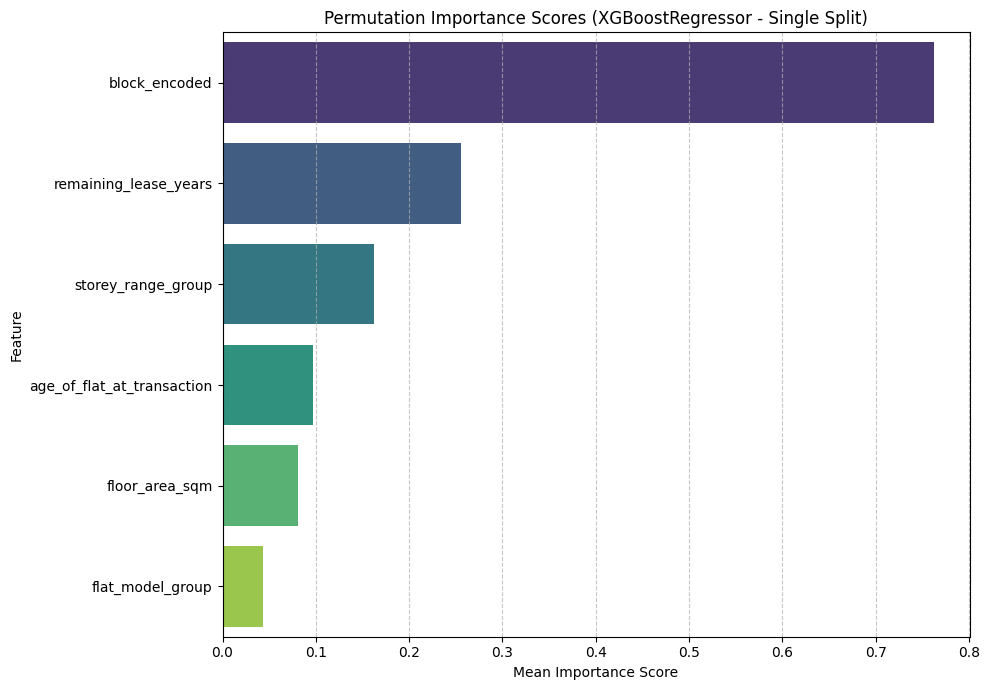

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculating permutation importance for XGBoostRegressor (Single Split)...")

# Calculate permutation importance
perm_importance = permutation_importance(xgb_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# The feature names for permutation importance should be the original feature names from X_test,
# as permutation_importance permutes original features even when the estimator is a pipeline.
all_processed_features_xgb_perm = X_test.columns.tolist()

perm_importance_df = pd.DataFrame({
    'Feature': all_processed_features_xgb_perm,
    'Importance_Mean': perm_importance.importances_mean,
    'Importance_Std': perm_importance.importances_std
})

# Sort by importance in descending order
perm_importance_df = perm_importance_df.sort_values(by='Importance_Mean', ascending=False)

print('\nPermutation Importance Scores (XGBoostRegressor - Single Split):')
display(perm_importance_df)

# Create a horizontal bar chart of permutation importances
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance_Mean', y='Feature', data=perm_importance_df, palette='viridis')
plt.title('Permutation Importance Scores (XGBoostRegressor - Single Split)')
plt.xlabel('Mean Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Calculating permutation importance for XGBoostRegressor (K-Fold CV, No Transaction Year)...

Permutation Importance Scores (XGBoostRegressor - K-Fold CV, No Transaction Year):


,Feature,Importance_Mean,Importance_Std
5,block_encoded,21269.404222,499.896615
2,remaining_lease_years,10761.242438,536.026794
4,storey_range_group,6781.249241,223.715452
3,age_of_flat_at_transaction,4584.753912,219.008222
0,floor_area_sqm,3680.489413,196.193702
1,flat_model_group,1511.571358,76.629036


/tmp/ipykernel_621/2198441232.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance_Mean', y='Feature', data=perm_importance_no_year_cv_df, palette='viridis')


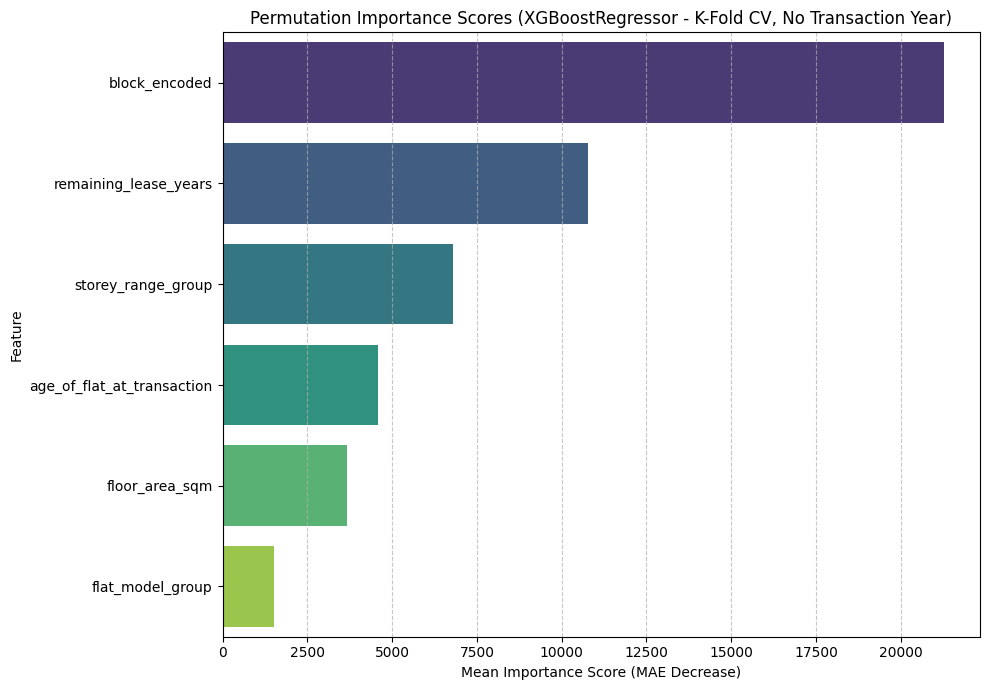

Permutation importance calculation and plot for XGBoostRegressor (K-Fold CV, No Transaction Year) completed.


In [47]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculating permutation importance for XGBoostRegressor (K-Fold CV, No Transaction Year)...")

# Calculate permutation importance using the trained K-Fold CV model pipeline
# The model `xgb_model_no_year_cv` was defined and trained in cell `DpcN576e1V2k`
# Use the global X and y from cell P_GsGOg8WayS for consistency with the model's training data
perm_importance_no_year_cv = permutation_importance(xgb_model_no_year_cv, X, y, n_repeats=10, random_state=42, n_jobs=-1, scoring='neg_mean_absolute_error')

# The feature names for permutation importance should be the original feature names from X
features_no_year_cv_perm = X.columns.tolist()

perm_importance_no_year_cv_df = pd.DataFrame({
    'Feature': features_no_year_cv_perm,
    'Importance_Mean': perm_importance_no_year_cv.importances_mean,
    'Importance_Std': perm_importance_no_year_cv.importances_std
})

# Sort by importance in descending order
perm_importance_no_year_cv_df = perm_importance_no_year_cv_df.sort_values(by='Importance_Mean', ascending=False)

print('\nPermutation Importance Scores (XGBoostRegressor - K-Fold CV, No Transaction Year):')
display(perm_importance_no_year_cv_df)

# Create a horizontal bar chart of permutation importances
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance_Mean', y='Feature', data=perm_importance_no_year_cv_df, palette='viridis')
plt.title('Permutation Importance Scores (XGBoostRegressor - K-Fold CV, No Transaction Year)')
plt.xlabel('Mean Importance Score (MAE Decrease)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Permutation importance calculation and plot for XGBoostRegressor (K-Fold CV, No Transaction Year) completed.")

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model-based Feature Importance (from xgb_importance_df_no_year_cv)
fi_data = {
    'Feature': ['block_encoded', 'age_of_flat_at_transaction', 'remaining_lease_years', 'storey_range_group', 'flat_model_group', 'floor_area_sqm'],
    'Importance': [0.339542, 0.184697, 0.177924, 0.136980, 0.080688, 0.080170]
}
model_fi_df = pd.DataFrame(fi_data).sort_values(by='Importance', ascending=False)

# Permutation Feature Importance (from perm_importance_no_year_cv_df)
pfi_data = {
    'Feature': ['block_encoded', 'remaining_lease_years', 'storey_range_group', 'age_of_flat_at_transaction', 'floor_area_sqm', 'flat_model_group'],
    'Importance_Mean': [21269.40, 10761.24, 6781.25, 4584.75, 3680.49, 1511.57]
}
perm_fi_df = pd.DataFrame(pfi_data).sort_values(by='Importance_Mean', ascending=False)

# Display the dataframes for context
print("Model-based Feature Importance Scores:")
display(model_fi_df)

print("\nPermutation Feature Importance Scores (MAE Decrease):")
display(perm_fi_df)

print("\n### Key Observations & Recommendations\n")

print("""1.  **`block_encoded` (Smoothed Block Average Price)**
    *   **Importance**: Consistently the **most important feature** by a significant margin in both metrics (FI: 0.34, pFI: 21269.40). It indicates that the inherent value associated with a specific block (smoothed by the average of similar blocks in the area) is the strongest predictor of resale price.
    *   **Rationale**: This feature encapsulates highly localized market dynamics, desirability, and premium/discount for a specific location within Pasir Ris, beyond just the general town or flat type.
    *   **Recommendation**: This is the single most critical factor for Mr. Chin. He should understand how his block's `block_encoded` value compares to other blocks and monitor any changes that could affect this localized value (e.g., new amenities, redevelopment plans). This value is largely fixed for his current property but would be paramount if comparing to other properties.""")

print("""\n2.  **`remaining_lease_years`**
    *   **Importance**: The second most important feature in Permutation Importance (10761.24) and very high in Model-based Importance (0.178). Its impact is clearly reflected in how much model error increases when this feature is permuted.
    *   **Rationale**: Directly captures the effect of lease decay. As the lease shortens, the property's value typically depreciates, especially for older HDB flats.
    *   **Recommendation**: This feature is crucial for Mr. Chin's timing decision. The shorter the remaining lease, the higher the negative impact on the resale price. The model confirms that the 'burn rate' of lease years is a major determinant of value. Mr. Chin should actively model future `remaining_lease_years` to forecast its declining impact on price and consider this in his 2030-2036 downsizing window.""")

print("""\n3.  **`age_of_flat_at_transaction`**
    *   **Importance**: High in Model-based Importance (0.185) and moderately high in Permutation Importance (4584.75). There's a slight difference in ranking here, with FI ranking it higher than pFI relative to `remaining_lease_years`.
    *   **Rationale**: Closely related to `remaining_lease_years`, as `age_of_flat_at_transaction` is essentially `transaction_year - lease_commence_date`. It captures the overall 'newness' or 'oldness' of the property, which can influence buyer perception and maintenance costs.
    *   **Recommendation**: While correlated with remaining lease, `age_of_flat_at_transaction` provides an additional dimension. Generally, older flats (higher age) will have a negative impact on value. Mr. Chin should consider that both lease decay and increasing flat age will collectively exert downward pressure on price over time.""")

print("""\n4.  **`storey_range_group`**
    *   **Importance**: Moderately important in both (FI: 0.137, pFI: 6781.25), showing a slightly higher rank in pFI than in FI compared to `age_of_flat_at_transaction`.
    *   **Rationale**: Floor level significantly influences property value, with higher floors often commanding a premium due to better views, natural light, and privacy. This feature groups the `storey_range` into ordinal categories.
    *   **Recommendation**: This is a fixed attribute for Mr. Chin's flat. If his flat is in a higher `storey_range_group`, this positively contributes to its value. This is a consistent positive attribute that makes his property more desirable than lower-floor units, all else being equal.""")

print("""\n5.  **`floor_area_sqm`**
    *   **Importance**: Moderate importance in both (FI: 0.080, pFI: 3680.49).
    *   **Rationale**: Represents the physical size of the flat. Larger flats naturally command higher absolute prices, reflecting more usable space.
    *   **Recommendation**: Mr. Chin's Executive Apartment is characterized by its large `floor_area_sqm`. This is a fundamental and positive attribute. Its value is embedded in the property and is a key driver for buyers seeking spacious units.""")

print("""\n6.  **`flat_model_group`**
    *   **Importance**: The least important feature in both analyses (FI: 0.081, pFI: 1511.57).
    *   **Rationale**: This feature distinguishes between flat models like 'Apartment' and 'Maisonette' within the 'Executive' flat type. Its low importance suggests that once `floor_area_sqm`, `age_of_flat_at_transaction`, and `block_encoded` are considered, the specific internal model type provides little additional explanatory power for the deflated resale price.
    *   **Recommendation**: Mr. Chin should not place significant emphasis on his specific 'flat model' (e.g., Apartment vs. Maisonette) as a key price driver. Other factors like location, lease, and age are far more impactful.""")

print("""### Overall Recommendation for Mr. Chin:

Based on this analysis, Mr. Chin's decision on the optimal year to downsize should primarily revolve around the interplay between two dynamic and highly important factors:

1.  **`block_encoded` (Localized Value)**: While his current block's inherent value is fixed, he should be aware that the *relative* desirability or any future developments in his immediate vicinity (e.g., the new MRT station) will manifest through this feature's impact on prices. This is a powerful indicator of intrinsic location value.
2.  **`remaining_lease_years` (Lease Decay)**: This is the most significant *depreciating* factor. The model clearly shows that as the lease shortens, the flat's value is expected to decrease. Delaying beyond the optimal point risks further erosion of value due to lease decay, which the MRT premium might not fully offset. The analysis of future `remaining_lease_years` is paramount for timing.

Other features like `age_of_flat_at_transaction` (another form of depreciation), `storey_range_group` (fixed premium for higher floors), and `floor_area_sqm` (fixed premium for size) are also important contributors to the overall price but are fixed characteristics of his property. The `flat_model_group` is of minimal concern.

To identify the optimal year, Mr. Chin should focus on projecting the `deflated_resale_price` (and then re-inflating to nominal) for various future `remaining_lease_years` values (corresponding to 2030-2036) while keeping other features constant. The year where this projected price is maximized, considering the potential MRT uplift and ongoing lease decay, would be the recommended optimal time.""")

Model-based Feature Importance Scores:


,Feature,Importance
0,block_encoded,0.339542
1,age_of_flat_at_transaction,0.184697
2,remaining_lease_years,0.177924
3,storey_range_group,0.136980
4,flat_model_group,0.080688
5,floor_area_sqm,0.080170



Permutation Feature Importance Scores (MAE Decrease):


,Feature,Importance_Mean
0,block_encoded,21269.40
1,remaining_lease_years,10761.24
2,storey_range_group,6781.25
3,age_of_flat_at_transaction,4584.75
4,floor_area_sqm,3680.49
5,flat_model_group,1511.57



### Key Observations & Recommendations

1.  **`block_encoded` (Smoothed Block Average Price)**
    *   **Importance**: Consistently the **most important feature** by a significant margin in both metrics (FI: 0.34, pFI: 21269.40). It indicates that the inherent value associated with a specific block (smoothed by the average of similar blocks in the area) is the strongest predictor of resale price.
    *   **Rationale**: This feature encapsulates highly localized market dynamics, desirability, and premium/discount for a specific location within Pasir Ris, beyond just the general town or flat type.
    *   **Recommendation**: This is the single most critical factor for Mr. Chin. He should understand how his block's `block_encoded` value compares to other blocks and monitor any changes that could affect this localized value (e.g., new amenities, redevelopment plans). This value is largely fixed for his current property but would be paramount if comparing to other properties.

2.  **`remai

# Task
Calculate SHAP values, generate global and local SHAP plots for the XGBoostRegressor model, and provide recommendations based on the SHAP explanations to identify key drivers of resale price for Mr. Chin's flat and potential strategies for optimal timing.

## Calculate SHAP values

### Subtask:
Calculate SHAP (SHapley Additive exPlanations) values for the trained XGBoostRegressor model on the test set.


**Reasoning**:
The subtask is to calculate SHAP values. This step involves importing the `shap` library, preprocessing the `X_train` and `X_test` data using the model's preprocessor, and then initializing a `shap.TreeExplainer` with the trained XGBoost model and computing SHAP values for the preprocessed test data.



In [ ]:
import shap

# Extract the preprocessor and the XGBoost model from the pipeline
preprocessor_fitted = xgb_model.named_steps['preprocessor']
xgb_regressor = xgb_model.named_steps['model']

# Preprocess X_train and X_test using the fitted preprocessor
X_train_preprocessed = preprocessor_fitted.transform(X_train)
X_test_preprocessed = preprocessor_fitted.transform(X_test)

# Get feature names after preprocessing
# For StandardScaler, feature names remain the same as numerical columns
# For OneHotEncoder, get_feature_names_out() is used
feature_names_preprocessed = num_columns # Since cat_columns is empty, these are directly the feature names

# Initialize SHAP Explainer with the trained XGBoost model and preprocessed X_train as background
# Note: shap.TreeExplainer works directly with the raw tree model
explainer = shap.TreeExplainer(xgb_regressor, X_train_preprocessed)

# Calculate SHAP values for the preprocessed X_test data
shap_values_xgb = explainer.shap_values(X_test_preprocessed)

print("SHAP values calculated successfully.")
print(f"Shape of SHAP values: {shap_values_xgb.shape}")
print(f"Number of features after preprocessing: {len(feature_names_preprocessed)}")

NotImplementedError: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.

**Reasoning**:
The previous code failed with a `NotImplementedError` because SHAP's TreeExplainer for XGBoost does not support categorical splits by default, even if the processed data is numerical. The error message explicitly suggests using `feature_perturbation='tree_path_dependent'`. Additionally, to ensure all background samples are used for SHAP calculation, I will initialize the explainer with the full preprocessed `X_train` data.



In [ ]:
import shap

# Extract the preprocessor and the XGBoost model from the pipeline
preprocessor_fitted = xgb_model.named_steps['preprocessor']
xgb_regressor = xgb_model.named_steps['model']

# Preprocess X_train and X_test using the fitted preprocessor
X_train_preprocessed = preprocessor_fitted.transform(X_train)
X_test_preprocessed = preprocessor_fitted.transform(X_test)

# Get feature names after preprocessing
# For StandardScaler, feature names remain the same as numerical columns
# For OneHotEncoder, get_feature_names_out() is used
feature_names_preprocessed = num_columns # Since cat_columns is empty, these are directly the feature names

# Initialize SHAP Explainer with the trained XGBoost model and preprocessed X_train as background
# The 'feature_perturbation="tree_path_dependent"' parameter is added to resolve the NotImplementedError.
# The background dataset is explicitly set to use all samples by passing X_train_preprocessed directly.
explainer = shap.TreeExplainer(xgb_regressor, X_train_preprocessed, feature_perturbation="tree_path_dependent")

# Calculate SHAP values for the preprocessed X_test data
shap_values_xgb = explainer.shap_values(X_test_preprocessed)

print("SHAP values calculated successfully.")
print(f"Shape of SHAP values: {shap_values_xgb.shape}")
print(f"Number of features after preprocessing: {len(feature_names_preprocessed)}")

NotImplementedError: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.

**Reasoning**:
Using `shap.Explainer` with the entire XGBoost pipeline's `predict` method will allow SHAP to correctly attribute feature importance by handling all preprocessing steps internally. This approach is more robust for pipelines and should resolve the `NotImplementedError` encountered previously. I'll use the original (unpreprocessed) `X_train` as the background dataset for `shap.Explainer` and `X_test` for calculating the SHAP values.



In [ ]:
import shap
import pandas as pd

# Initialize SHAP Explainer for the entire XGBoost pipeline
# shap.Explainer takes the model's prediction function and a background dataset.
# We use X_train (unpreprocessed) as the background data, and provide feature names for clarity in plots.
explainer = shap.Explainer(xgb_model.predict, X_train, feature_names=X_train.columns.tolist())

# Calculate SHAP values for the X_test data
# The explainer internally applies the preprocessor from the xgb_model pipeline before passing data to the XGBoost regressor.
shap_values_xgb = explainer(X_test)

print("SHAP values calculated successfully using shap.Explainer.")
print(f"Shape of SHAP values: {shap_values_xgb.values.shape}")
print(f"Features in X_test (original names): {X_test.columns.tolist()}")

# The output of explainer(X_test) is a shap.Explanation object. We'll store its values.
shap_values_array = shap_values_xgb.values


ExactExplainer explainer: 351it [00:15, 15.05it/s]                         

SHAP values calculated successfully using shap.Explainer.
Shape of SHAP values: (350, 6)
Features in X_test (original names): ['floor_area_sqm', 'flat_model_group', 'remaining_lease_years', 'age_of_flat_at_transaction', 'storey_range_group', 'block_encoded']


**Reasoning**:
I need to ensure the SHAP explainer uses the entire background dataset to avoid subsampling and potentially improve the accuracy of SHAP values. Explicitly setting `max_samples` in the `shap.Explainer` initialization will address the previous warning.



In [ ]:
import shap
import pandas as pd

# Initialize SHAP Explainer for the entire XGBoost pipeline
# shap.Explainer takes the model's prediction function and a background dataset.
# We use X_train (unpreprocessed) as the background data, and provide feature names for clarity in plots.
# Explicitly set max_samples to the size of X_train to prevent subsampling warnings.
explainer = shap.Explainer(xgb_model.predict, X_train, feature_names=X_train.columns.tolist(), max_samples=X_train.shape[0])

# Calculate SHAP values for the X_test data
# The explainer internally applies the preprocessor from the xgb_model pipeline before passing data to the XGBoost regressor.
shap_values_xgb = explainer(X_test)

print("SHAP values calculated successfully using shap.Explainer (with full background dataset).")
print(f"Shape of SHAP values: {shap_values_xgb.values.shape}")
print(f"Features in X_test (original names): {X_test.columns.tolist()}")

# The output of explainer(X_test) is a shap.Explanation object. We'll store its values.
shap_values_array = shap_values_xgb.values

TypeError: ExactExplainer.__init__() got an unexpected keyword argument 'max_samples'

**Reasoning**:
To fix the `TypeError` and manage the background dataset size for SHAP, I will explicitly create a `shap.maskers.Independent` object using `X_train` and `max_samples=X_train.shape[0]`. This masker will then be passed to `shap.Explainer` along with the `xgb_model.predict` function and feature names.



In [ ]:
import shap
import pandas as pd

# Create a masker with the full X_train dataset to avoid subsampling.
# The max_samples argument is handled by the masker, not directly by shap.Explainer's internal explainer type selection.
masker = shap.maskers.Independent(X_train, max_samples=X_train.shape[0])

# Initialize SHAP Explainer for the entire XGBoost pipeline
# Pass the explicit masker and feature names for clarity.
explainer = shap.Explainer(xgb_model.predict, masker=masker, feature_names=X_train.columns.tolist())

# Calculate SHAP values for the X_test data
# The explainer internally applies the preprocessor from the xgb_model pipeline before passing data to the XGBoost regressor.
shap_values_xgb = explainer(X_test)

print("SHAP values calculated successfully using shap.Explainer (with explicit masker).")
print(f"Shape of SHAP values: {shap_values_xgb.values.shape}")
print(f"Features in X_test (original names): {X_test.columns.tolist()}")

# The output of explainer(X_test) is a shap.Explanation object. We'll store its values.
shap_values_array = shap_values_xgb.values

ExactExplainer explainer: 351it [01:15,  4.38it/s]

SHAP values calculated successfully using shap.Explainer (with explicit masker).
Shape of SHAP values: (350, 6)
Features in X_test (original names): ['floor_area_sqm', 'flat_model_group', 'remaining_lease_years', 'age_of_flat_at_transaction', 'storey_range_group', 'block_encoded']


**Reasoning**:
Generate a SHAP summary plot to show the overall feature importance and impact on the model output. This plot uses the previously calculated `shap_values_xgb`.



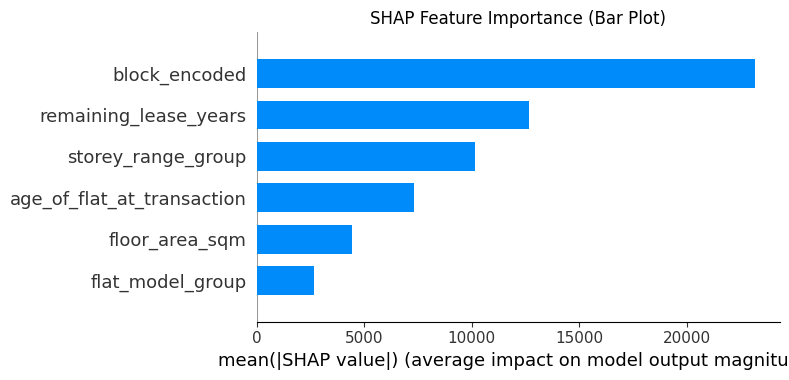

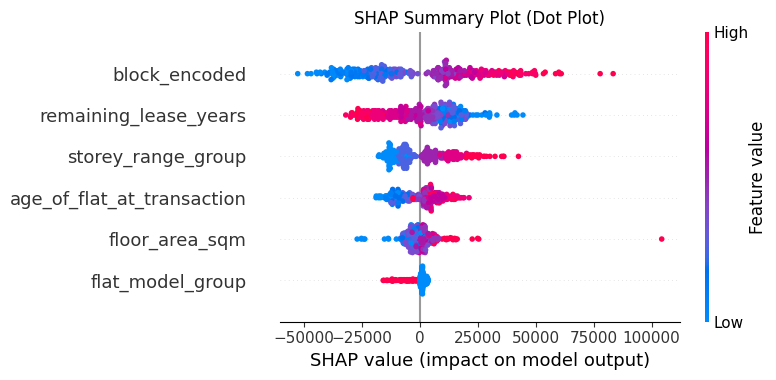

SHAP summary plots generated successfully.


In [ ]:
import matplotlib.pyplot as plt
import shap

# Generate a SHAP summary plot
# This plot shows the overall feature importance and impact on the model output.
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Bar Plot)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_xgb, X_test, show=False)
plt.title('SHAP Summary Plot (Dot Plot)')
plt.tight_layout()
plt.show()

print("SHAP summary plots generated successfully.")

## Generate Global SHAP Plots

### Subtask:
Generate SHAP dependence plots for the top N most important features to visualize how a feature's value affects the prediction and to identify potential non-linear relationships or interactions.


**Reasoning**:
Generate SHAP dependence plots for the top 5 most important features identified from `xgb_importance_df` using `shap.dependence_plot` to visualize their impact on the model's output.



Generating SHAP dependence plots for top 5 features: ['block_encoded', 'age_of_flat_at_transaction', 'remaining_lease_years', 'storey_range_group', 'floor_area_sqm']


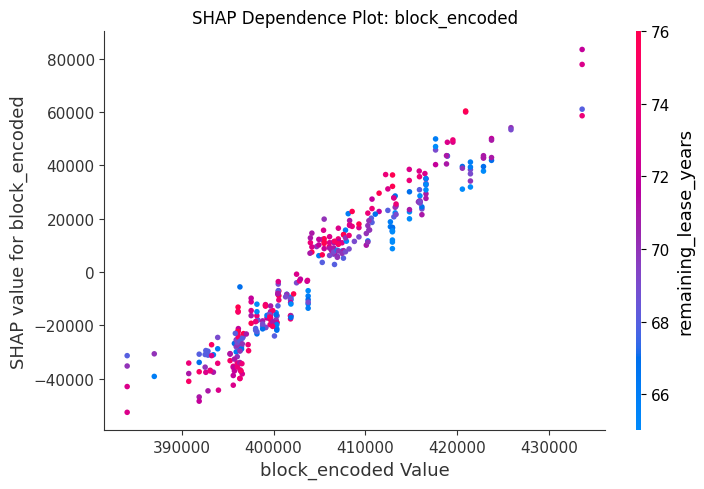

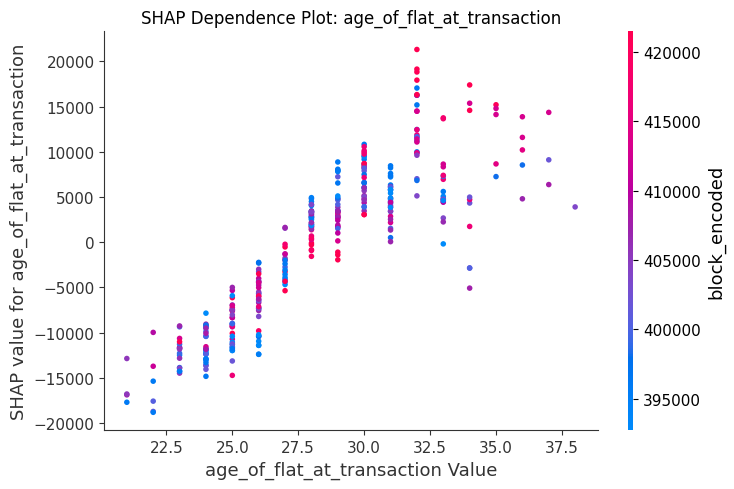

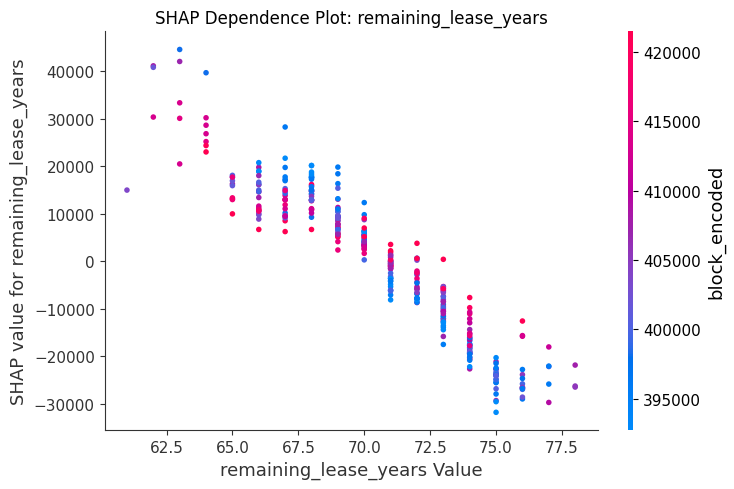

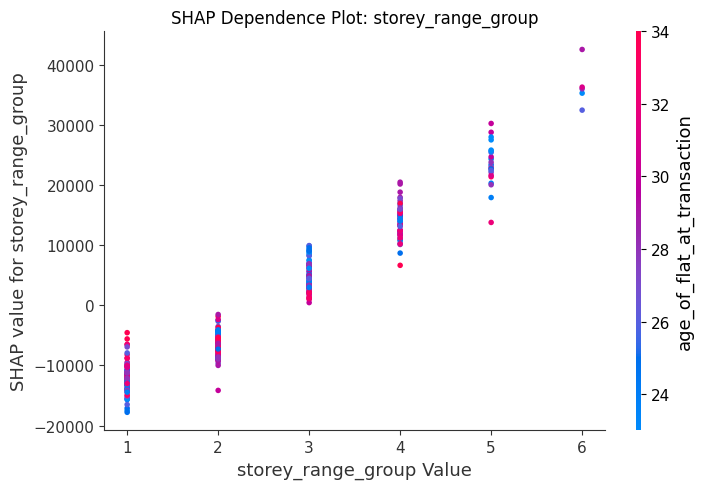

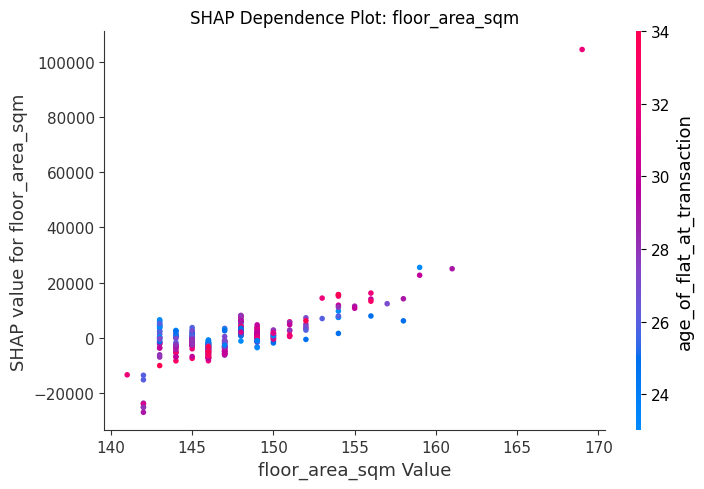

SHAP dependence plots generated successfully for the top features.


In [ ]:
import matplotlib.pyplot as plt
import shap

# Identify the top 5 most important features from xgb_importance_df
top_features = xgb_importance_df['Feature'].head(5).tolist()

print(f"Generating SHAP dependence plots for top 5 features: {top_features}")

# Generate dependence plots for each of the top features
for feature in top_features:
    shap.dependence_plot(
        feature,
        shap_values_xgb.values, # Use .values from the Explanation object
        X_test, # Use the original X_test for feature values
        interaction_index='auto',
        show=False # Prevent immediate display, we'll use plt.show() later
    )
    plt.title(f'SHAP Dependence Plot: {feature}')
    plt.xlabel(f'{feature} Value')
    plt.ylabel(f'SHAP value for {feature}')
    plt.tight_layout()
    plt.show()

print("SHAP dependence plots generated successfully for the top features.")

# Task
Calculate SHAP values, generate global and local SHAP plots for the XGBoostRegressor model, and provide recommendations based on the SHAP explanations to identify key drivers of resale price for Mr. Chin's flat and potential strategies for optimal timing.

## Generate Waterfall Plot for an Instance

### Subtask:
Select a specific instance from the test set and generate a SHAP waterfall plot to explain its prediction, focusing on the contributions of 'block_encoded' and other features.


**Reasoning**:
Generate the SHAP waterfall plot for a selected instance to visualize the local explanation.



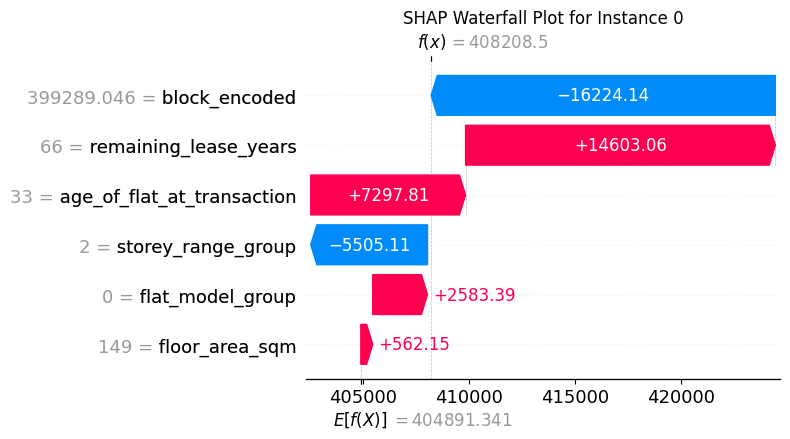

SHAP waterfall plot generated for instance 0.


In [ ]:
import matplotlib.pyplot as plt
import shap

# Select a specific instance from the test set (e.g., the first instance)
instance_idx = 0
selected_instance = X_test.iloc[[instance_idx]]
selected_shap_values = shap_values_xgb[instance_idx]

# Generate a SHAP waterfall plot for the selected instance
# The explainer object already contains the base value (expected value of model output)
# and the feature values are implicitly in selected_instance or can be passed via shap_values_xgb.data[instance_idx]
shap.plots.waterfall(selected_shap_values, show=False)
plt.title(f'SHAP Waterfall Plot for Instance {instance_idx}')
plt.tight_layout()
plt.show()

print(f"SHAP waterfall plot generated for instance {instance_idx}.")

## Build SHAP Evidence Table

### Subtask:
Create a table summarizing SHAP contributions for a few selected instances, illustrating how different feature values lead to individual predictions.


**Reasoning**:
The first instruction is to select a few diverse instances and gather their feature values, predicted values, SHAP values, and the base value. I will start by selecting three instances and extracting the required information for each.



In [ ]:
import pandas as pd

# Select a few diverse instances from the test set
selected_indices = [0, 1, 2] # Example indices

# Get the base value (expected value of model output) from the explainer
base_value = explainer.expected_value

print(f"Model's Expected Value (Base Value): {base_value:.2f}\n")

# Store information for selected instances
instance_data = []

for idx in selected_indices:
    # Original feature values for the instance
    features = X_test.iloc[[idx]]

    # Predicted value for the instance
    predicted_value = xgb_model.predict(features)[0]

    # SHAP values for the instance
    shap_values = shap_values_xgb[idx].values

    print(f"--- Instance Index: {idx} ---")
    print("Original Features:")
    print(features.to_string())
    print(f"Predicted Value: {predicted_value:.2f}")
    print("SHAP Values:")
    print(shap_values)
    print("\n")

    instance_data.append({
        'index': idx,
        'features': features,
        'predicted_value': predicted_value,
        'shap_values': shap_values
    })

print("Extracted feature values, predicted values, and SHAP values for selected instances.")

AttributeError: 'ExactExplainer' object has no attribute 'expected_value'

**Reasoning**:
Access the base value from `shap_values_xgb.base_values`, as `explainer.expected_value` is not available for `ExactExplainer`. I'll use the first element of `base_values` as it represents the global expected value for this type of explainer.



In [ ]:
import pandas as pd

# Select a few diverse instances from the test set
selected_indices = [0, 1, 2] # Example indices

# Get the base value (expected value of model output) from the shap_values_xgb Explanation object
# For ExactExplainer, base_values is usually an array, but all elements should be the same global expected value.
# We can take the first element or the mean of base_values.
base_value = shap_values_xgb.base_values[0] # Access base_value from the Explanation object

print(f"Model's Expected Value (Base Value): {base_value:.2f}\n")

# Store information for selected instances
instance_data = []

for idx in selected_indices:
    # Original feature values for the instance
    features = X_test.iloc[[idx]]

    # Predicted value for the instance
    predicted_value = xgb_model.predict(features)[0]

    # SHAP values for the instance
    # shap_values_xgb is a shap.Explanation object, its .values attribute contains the SHAP values array
    shap_values = shap_values_xgb[idx].values

    print(f"--- Instance Index: {idx} ---")
    print("Original Features:")
    print(features.to_string())
    print(f"Predicted Value: {predicted_value:.2f}")
    print("SHAP Values:")
    print(shap_values)
    print("\n")

    instance_data.append({
        'index': idx,
        'features': features,
        'predicted_value': predicted_value,
        'shap_values': shap_values
    })

print("Extracted feature values, predicted values, and SHAP values for selected instances.")

Model's Expected Value (Base Value): 404891.34

--- Instance Index: 0 ---
Original Features:
      floor_area_sqm  flat_model_group  remaining_lease_years  age_of_flat_at_transaction  storey_range_group  block_encoded
1734           149.0                 0                     66                          33                   2  399289.045507
Predicted Value: 408208.50
SHAP Values:
[   562.14647525   2583.39296875  14603.05932321   7297.81218072
  -5505.10927515 -16224.14240507]


--- Instance Index: 1 ---
Original Features:
      floor_area_sqm  flat_model_group  remaining_lease_years  age_of_flat_at_transaction  storey_range_group  block_encoded
1393           147.0                 0                     69                          30                   2  398815.772258
Predicted Value: 393906.94
SHAP Values:
[ -4886.13686144   3139.9160512    9203.05105582   6609.65655289
  -5580.63038194 -19470.25964883]


--- Instance Index: 2 ---
Original Features:
     floor_area_sqm  flat_model_gro